In [1]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from google.oauth2 import service_account

# 1. 신분증(JSON 키) 경로 지정
KEY_PATH = '../google_key.json'

# 2. 인증 객체 생성
credentials = service_account.Credentials.from_service_account_file(KEY_PATH)

# 3. 프로젝트 ID 설정
project_id = 'gdelt-analysis-494301'

# 4. 데이터 불러오기
query = "SELECT SQLDATE FROM `gdelt-bq.full.events` LIMIT 5"
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("인증 성공! 데이터를 가져왔습니다.")

Downloading: 100%|██████████|
인증 성공! 데이터를 가져왔습니다.


In [2]:
# 1. 고위험군 CAMEO 코드 리스트
target_cameo_codes = [
    '150', '151', '152', '153', '154', '155', 
    '190', '191', '192', '193', '194', '195', '196', 
    '200', '201', '202', '203', '204'
]
formatted_codes = ", ".join([f"'{code}'" for code in target_cameo_codes])

query = f"""
SELECT 
    SQLDATE, 
    EventCode,
    IsRootEvent,
    GoldsteinScale, 
    NumMentions, 
    AvgTone,
    ActionGeo_Type,
    ActionGeo_Lat, 
    ActionGeo_Long, 
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE SQLDATE >= 20130401 
  AND (
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
  AND EventCode IN ({formatted_codes})
  AND IsRootEvent = 1                 -- 핵심 사건만 필터링
  AND ActionGeo_Type IN (3, 4, 5)
"""

# 2. 데이터 불러오기
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("데이터 불러오기 완료")
display(df.head())

Downloading: 100%|██████████|
데이터 불러오기 완료


,SQLDATE,EventCode,IsRootEvent,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20160704,190,1,-10.0,4,-5.223881,4,42.8333,124.633,http://sputniknews.com/asia/20160705/104243613...
1,20160704,190,1,-10.0,4,-5.223881,4,42.8333,124.633,http://sputniknews.com/asia/20160705/104243613...
2,20160704,150,1,-7.2,2,1.892744,4,15.0000,115.000,http://thevillagessuntimes.com/2016/07/04/chin...
3,20160704,194,1,-10.0,4,-1.005747,4,23.5700,119.570,https://navaltoday.com/2016/07/01/taiwan-navy-...
4,20160704,194,1,-10.0,1,-1.005747,4,23.5700,119.570,https://navaltoday.com/2016/07/01/taiwan-navy-...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11897 entries, 0 to 11896
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SQLDATE         11897 non-null  Int64  
 1   EventCode       11897 non-null  object 
 2   IsRootEvent     11897 non-null  Int64  
 3   GoldsteinScale  11897 non-null  float64
 4   NumMentions     11897 non-null  Int64  
 5   AvgTone         11897 non-null  float64
 6   ActionGeo_Type  11897 non-null  Int64  
 7   ActionGeo_Lat   11897 non-null  float64
 8   ActionGeo_Long  11897 non-null  float64
 9   SOURCEURL       11897 non-null  object 
dtypes: Int64(4), float64(4), object(2)
memory usage: 976.1+ KB


In [4]:
df = df.drop(columns=['IsRootEvent'])
df.head()

,SQLDATE,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20160704,190,-10.0,4,-5.223881,4,42.8333,124.633,http://sputniknews.com/asia/20160705/104243613...
1,20160704,190,-10.0,4,-5.223881,4,42.8333,124.633,http://sputniknews.com/asia/20160705/104243613...
2,20160704,150,-7.2,2,1.892744,4,15.0000,115.000,http://thevillagessuntimes.com/2016/07/04/chin...
3,20160704,194,-10.0,4,-1.005747,4,23.5700,119.570,https://navaltoday.com/2016/07/01/taiwan-navy-...
4,20160704,194,-10.0,1,-1.005747,4,23.5700,119.570,https://navaltoday.com/2016/07/01/taiwan-navy-...


In [5]:
df.describe()

,SQLDATE,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long
count,11897.0,11897.000000,11897.0,11897.000000,11897.0,11897.000000,11897.000000
mean,20210860.178869,-8.817996,13.300412,-2.505625,3.993864,30.852349,109.916208
std,30686.42784,1.344023,51.402282,2.355780,0.248153,9.124798,39.478505
min,20130401.0,-10.000000,1.0,-18.181818,3.0,-41.300000,-157.972000
25%,20190905.0,-10.000000,2.0,-3.900584,4.0,24.650300,116.388000
50%,20220611.0,-10.000000,5.0,-2.523659,4.0,25.047800,118.318000
75%,20230803.0,-7.200000,10.0,-1.150748,4.0,39.928900,121.532000
max,20260504.0,-7.200000,1468.0,10.550459,5.0,67.939700,178.417000


In [6]:
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')

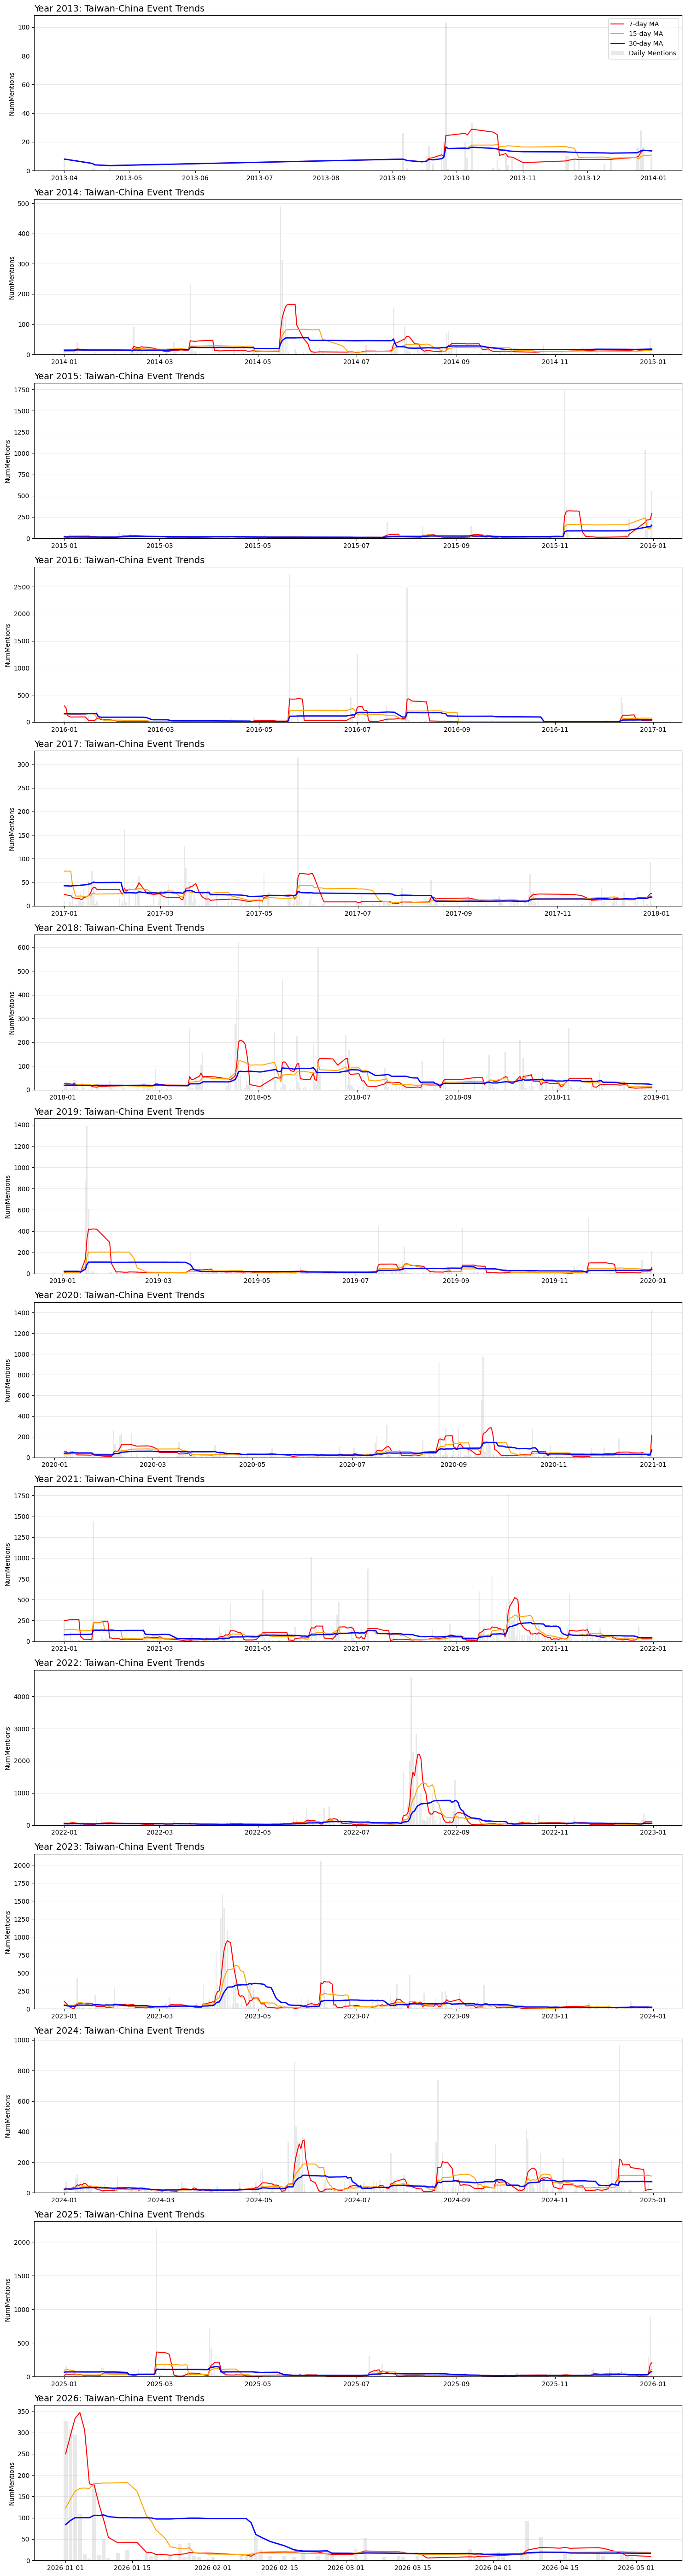

In [7]:
# 1. 전체 데이터에 대해 날짜별 합계(또는 평균) 계산
# SQLDATE 기준으로 그룹화하여 일별 전체 트렌드 생성
daily_all = df.groupby('SQLDATE')['NumMentions'].sum().reset_index()

# 2. 전체 기간에 대해 이동평균 미리 계산
daily_all['MA7'] = daily_all['NumMentions'].rolling(window=7, min_periods=1).mean()
daily_all['MA15'] = daily_all['NumMentions'].rolling(window=15, min_periods=1).mean()
daily_all['MA30'] = daily_all['NumMentions'].rolling(window=30, min_periods=1).mean()

# 3. 연도 컬럼 생성 및 연도 리스트 추출
daily_all['Year'] = daily_all['SQLDATE'].dt.year
years = sorted(daily_all['Year'].unique())
n_years = len(years)

# 4. 시각화 설정
fig, axes = plt.subplots(n_years, 1, figsize=(15, 4 * n_years), sharex=False)

if n_years == 1:
    axes = [axes]

for i, year in enumerate(years):
    # 이미 계산된 전체 데이터에서 해당 연도만 슬라이싱
    yearly_data = daily_all[daily_all['Year'] == year]
    
    ax = axes[i]
    
    # 배경 막대
    ax.bar(yearly_data['SQLDATE'], yearly_data['NumMentions'], color='lightgrey', alpha=0.5, label='Daily Mentions')
    
    # 이동평균선
    ax.plot(yearly_data['SQLDATE'], yearly_data['MA7'], color='red', linewidth=1.5, label='7-day MA')
    ax.plot(yearly_data['SQLDATE'], yearly_data['MA15'], color='orange', linewidth=1.5, label='15-day MA')
    ax.plot(yearly_data['SQLDATE'], yearly_data['MA30'], color='blue', linewidth=2, label='30-day MA')

    # 그래프 꾸미기
    ax.set_title(f'Year {year}: Taiwan-China Event Trends', fontsize=14, loc='left')
    ax.set_ylabel('NumMentions')
    ax.grid(True, axis='y', alpha=0.3)
    
    # x축 날짜 포맷 최적화
    ax.tick_params(axis='x', rotation=0)
    
    if i == 0:
        ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

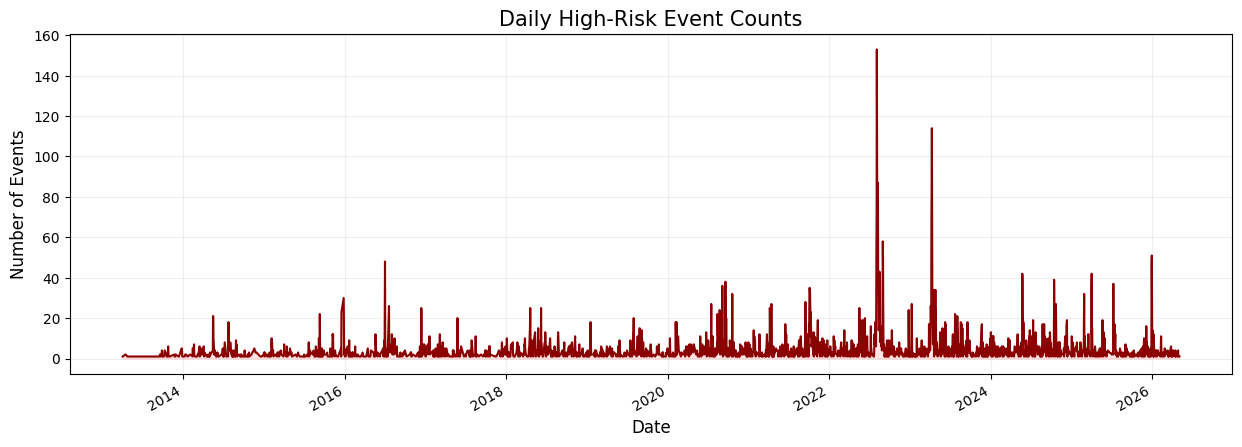

In [8]:
# 날짜별 사건 빈도
daily_counts = df.groupby('SQLDATE').size()

plt.figure(figsize=(15, 5))
daily_counts.plot(color='darkred', linewidth=1.5)

plt.title('Daily High-Risk Event Counts', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Events', fontsize=12)
plt.fill_between(daily_counts.index, daily_counts.values, color='red', alpha=0.1) # 아래 영역 채우기
plt.grid(True, alpha=0.2)
plt.show()

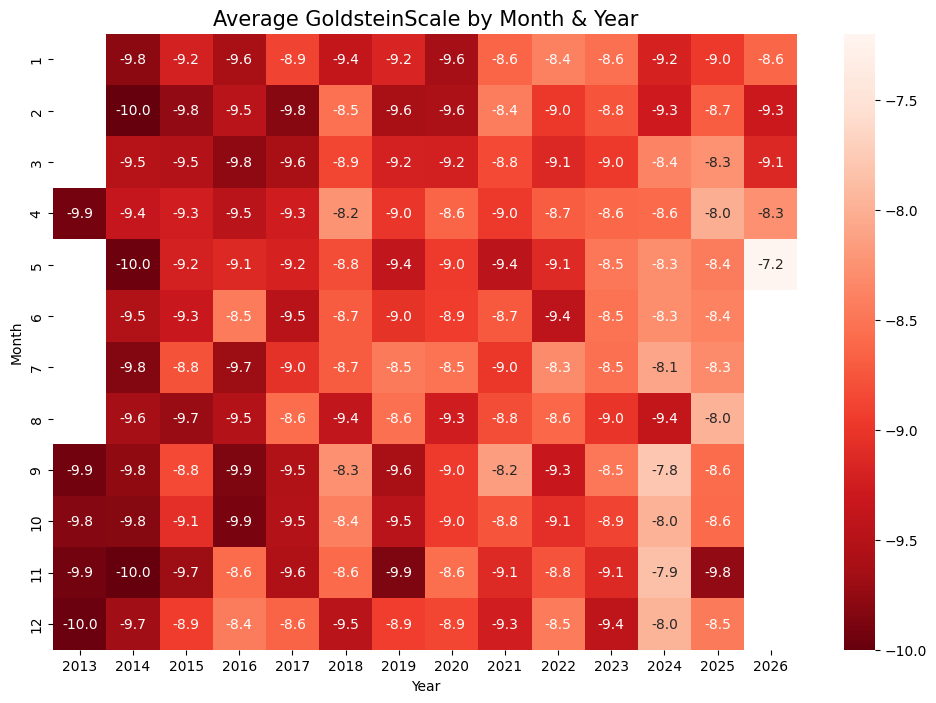

In [9]:
# 연도와 월 컬럼 생성
df['Year'] = df['SQLDATE'].dt.year
df['Month'] = df['SQLDATE'].dt.month

# 월별 평균 GoldsteinScale 피벗 테이블
pivot_df = df.pivot_table(index='Month', columns='Year', values='GoldsteinScale', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, cmap='Reds_r', fmt=".1f") # Reds_r은 낮은 값(더 위험)이 진하게 표시됨
plt.title('Average GoldsteinScale by Month & Year', fontsize=15)
plt.show()

--- 기사량 증가율 통계 ---
count         2415.0
mean      331.512922
std      1611.581333
min       -99.561404
50%              0.0
75%            170.0
90%            700.0
95%           1400.0
99%           6967.4
max          30200.0
Name: GrowthRate, dtype: Float64


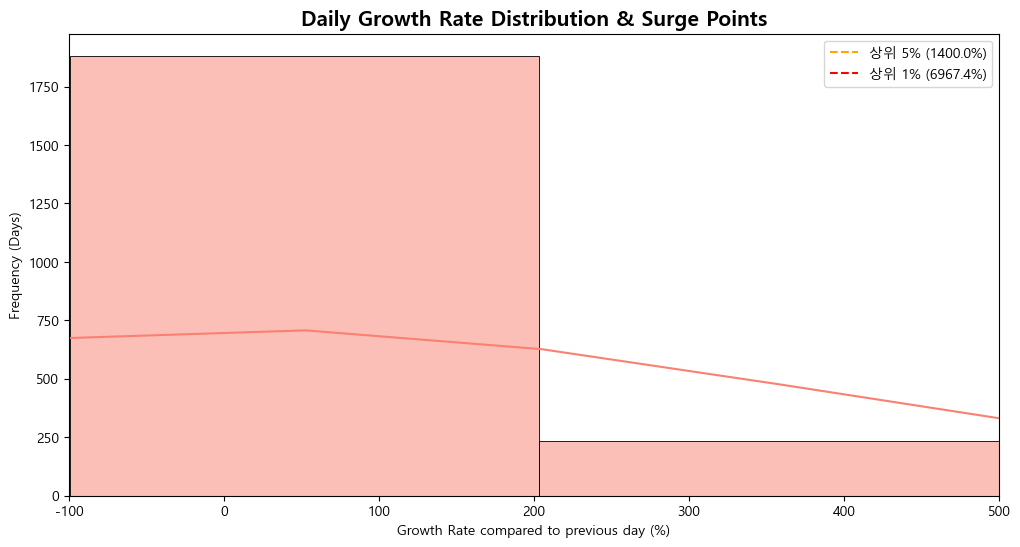


--- 역대급 기사 폭증일 (Growth Rate 상위 1%) ---


,SQLDATE,NumMentions,GrowthRate
1288,2021-09-15,606,30200.0
1251,2021-07-08,872,28966.666667
1793,2023-08-03,473,23550.0
873,2019-09-05,431,21450.0
384,2016-08-01,2480,20566.666667
379,2016-07-19,307,15250.0
1063,2020-09-18,555,13775.0
938,2020-02-06,266,13200.0
919,2019-12-25,130,12900.0
737,2018-11-08,259,12850.0


In [10]:
import numpy as np

# 한글 폰트 및 설정 (Windows 환경)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터를 날짜별로 집계 및 정렬
daily_vol = df.groupby('SQLDATE')['NumMentions'].sum().reset_index().sort_values('SQLDATE')

# 2. 전날 대비 증가율(%) 계산
daily_vol['GrowthRate'] = daily_vol['NumMentions'].pct_change() * 100

# 3.무한대(inf) 및 결측치 처리
daily_vol['GrowthRate'] = daily_vol['GrowthRate'].replace([np.inf, -np.inf], np.nan).fillna(0)

# 4. 증가율 백분위수(Percentiles) 산출
growth_stats = daily_vol['GrowthRate'].describe(percentiles=[.5, .75, .9, .95, .99])

print("--- 기사량 증가율 통계 ---")
print(growth_stats)

# 5. 시각화: 증가율 분포와 임계점 확인
plt.figure(figsize=(12, 6))
sns.histplot(daily_vol['GrowthRate'], bins=100, kde=True, color='salmon')

# 상위 5% 및 1% 증가율 지점 표시
plt.axvline(growth_stats['95%'], color='orange', linestyle='--', label=f'상위 5% ({growth_stats["95%"]:.1f}%)')
plt.axvline(growth_stats['99%'], color='red', linestyle='--', label=f'상위 1% ({growth_stats["99%"]:.1f}%)')

plt.title('Daily Growth Rate Distribution & Surge Points', fontsize=15, fontweight='bold')
plt.xlabel('Growth Rate compared to previous day (%)')
plt.ylabel('Frequency (Days)')
plt.xlim(-100, 500) # 가독성을 위해 극단적 수치 범위 제한
plt.legend()
plt.show()

# 6. 상위 1% 폭증일 리스트 추출
top_growth_days = daily_vol[daily_vol['GrowthRate'] >= growth_stats['99%']].sort_values(by='GrowthRate', ascending=False)
print("\n--- 역대급 기사 폭증일 (Growth Rate 상위 1%) ---")
display(top_growth_days.head(10))

In [45]:
import pandas as pd
import numpy as np

# 1. 원본 데이터 집계 (날짜별 기사량 합계)
daily_counts = df.groupby('SQLDATE')['NumMentions'].sum().reset_index().sort_values('SQLDATE')

# --- [Case A] 기사가 없는 날 제외 (Skip) ---
df_skip = daily_counts.copy()
df_skip['GrowthRate'] = df_skip['NumMentions'].pct_change() * 100

# --- [Case B] 기사가 없는 날을 0으로 채움 (Fill) ---
# 전체 날짜 생성 후 reindex로 0 채우기
all_dates = pd.date_range(start=daily_counts['SQLDATE'].min(), end=daily_counts['SQLDATE'].max())
df_fill = daily_counts.set_index('SQLDATE').reindex(all_dates).fillna(0).reset_index()
df_fill.columns = ['SQLDATE', 'NumMentions']
df_fill['GrowthRate'] = df_fill['NumMentions'].pct_change() * 100

# 2. 통계 계산 함수
def get_robust_stats(series):
    # 핵심 해결책: inf, -inf, NaN 값을 모두 무시하고 '순수한 숫자'만 추출
    clean_series = series[np.isfinite(series)]
    
    # 순수 숫자로만 통계 계산
    stats = clean_series.describe(percentiles=[.5, .75, .9, .95, .99])
    
    # 0건에서 기사가 발생하여 무한대(inf)가 된 횟수를 따로 계산해서 맨 밑에 추가
    inf_count = (series == np.inf).sum()
    stats['0 to N (Inf) Count'] = float(inf_count) # 타입을 float로 강제 통일
    
    return stats

# 3. 결과 표로 합치기
stats_compare = pd.DataFrame({
    'Case A: 없는 날 제외 (Skip)': get_robust_stats(df_skip['GrowthRate']),
    'Case B: 0건 포함 (Fill)': get_robust_stats(df_fill['GrowthRate'])
})

# 4. 출력
print("--- 전날 대비 기사량 증가율 통계 비교 ---")
display(stats_compare.round(2))

--- 전날 대비 기사량 증가율 통계 비교 ---


,Case A: 없는 날 제외 (Skip),Case B: 0건 포함 (Fill)
count,2414.0,2414.0
mean,331.65,168.83
std,1611.9,1322.89
min,-99.56,-100.0
50%,0.0,-71.43
75%,170.0,26.78
90%,700.0,349.73
95%,1400.0,892.83
99%,6973.3,3855.8
max,30200.0,30200.0


In [46]:
import pandas as pd
import numpy as np

# 1. 원본 데이터 집계
daily_counts = df.groupby('SQLDATE')['NumMentions'].sum().reset_index().sort_values('SQLDATE')

# ==========================================
# [Case A] 기사가 없는 날 제외 (Skip)
# ==========================================
df_skip = daily_counts.copy()
df_skip['PrevMentions'] = df_skip['NumMentions'].shift(1)
df_skip['GrowthRate'] = (df_skip['NumMentions'] - df_skip['PrevMentions']) / df_skip['PrevMentions'] * 100


# ==========================================
# [Case B] 기사가 없는 날을 0으로 채움 (Fill)
# ==========================================
all_dates = pd.date_range(start=daily_counts['SQLDATE'].min(), end=daily_counts['SQLDATE'].max())
df_fill = daily_counts.set_index('SQLDATE').reindex(all_dates).fillna(0).reset_index()
df_fill.columns = ['SQLDATE', 'NumMentions']

# 어제 데이터를 새 컬럼으로 복사
df_fill['PrevMentions'] = df_fill['NumMentions'].shift(1)

# 일단 전체 기본 공식으로 계산 (0 나누기 에러가 나더라도 일단 진행)
df_fill['GrowthRate'] = (df_fill['NumMentions'] - df_fill['PrevMentions']) / df_fill['PrevMentions'] * 100

# ★ 판다스 .loc를 활용하여 특수 케이스들만 안전하게 덮어쓰기
# 1. 0건 -> 0건 (증가율 0%)
mask_0_to_0 = (df_fill['PrevMentions'] == 0) & (df_fill['NumMentions'] == 0)
df_fill.loc[mask_0_to_0, 'GrowthRate'] = 0.0

# 2. 0건 -> N건 (무한대 폭증)
mask_0_to_N = (df_fill['PrevMentions'] == 0) & (df_fill['NumMentions'] > 0)
df_fill.loc[mask_0_to_N, 'GrowthRate'] = np.inf

# 3. 첫째 날 (비교 대상 없음)
mask_first = df_fill['PrevMentions'].isna()
df_fill.loc[mask_first, 'GrowthRate'] = np.nan


# ==========================================
# 2. 통계 계산 함수
# ==========================================
def get_final_stats(series):
    inf_count = (series == np.inf).sum()
    
    # inf와 nan을 완벽히 제거하고 순수 유한 숫자만 남김
    clean_series = series.replace([np.inf, -np.inf], np.nan).dropna()
    
    stats = clean_series.describe(percentiles=[.5, .75, .9, .95, .99])
    stats['0 to N (Inf) Count'] = float(inf_count)
    return stats


# ==========================================
# 3. 결과 합치기 및 출력
# ==========================================
stats_compare = pd.DataFrame({
    'Case A: 없는 날 제외 (Skip)': get_final_stats(df_skip['GrowthRate']),
    'Case B: 0건 포함 (Fill)': get_final_stats(df_fill['GrowthRate'])
})

print("--- 전날 대비 기사량 증가율 통계 비교 ---")
display(stats_compare.round(2))

--- 전날 대비 기사량 증가율 통계 비교 ---


,Case A: 없는 날 제외 (Skip),Case B: 0건 포함 (Fill)
count,2414.0,3937.0
mean,331.65,103.52
std,1611.9,1039.05
min,-99.56,-100.0
50%,0.0,0.0
75%,170.0,0.0
90%,700.0,148.0
95%,1400.0,474.83
99%,6973.3,2478.4
max,30200.0,30200.0


In [48]:
# 'GrowthRate'가 무한대(inf)인 날들만 필터링
inf_spikes = df_fill[df_fill['GrowthRate'] == np.inf]

# 그 날들 중에서 '실제 기사량(NumMentions)'이 가장 많았던 순서대로 정렬
top_inf_spikes = inf_spikes.sort_values(by='NumMentions', ascending=False).head(5)

print("--- 정적(0건)을 깨고 가장 크게 폭발한 날 TOP 5 ---")
display(top_inf_spikes[['SQLDATE', 'PrevMentions', 'NumMentions', 'GrowthRate']])

--- 정적(0건)을 깨고 가장 크게 폭발한 날 TOP 5 ---


,SQLDATE,PrevMentions,NumMentions,GrowthRate
1187,2016-07-01,0,1263,inf
1000,2015-12-27,0,1035,inf
2985,2021-06-03,0,1014,inf
2701,2020-08-23,0,917,inf
3020,2021-07-08,0,872,inf


 정적을 깨고 발생한 최대 일일 기사량: 1263건

--- 정적(0건)을 깨고 발생한 돌발 사건의 규모별 분포 ---


,Volume_Group,발생 일수(Days),비율(%)
0,1~50건,740,87.7
1,51~100건,48,5.7
2,101~150건,20,2.4
3,151~200건,9,1.1
4,201~300건,14,1.7
5,301~500건,5,0.6
6,501~1000건,5,0.6
7,1000건 초과,3,0.4


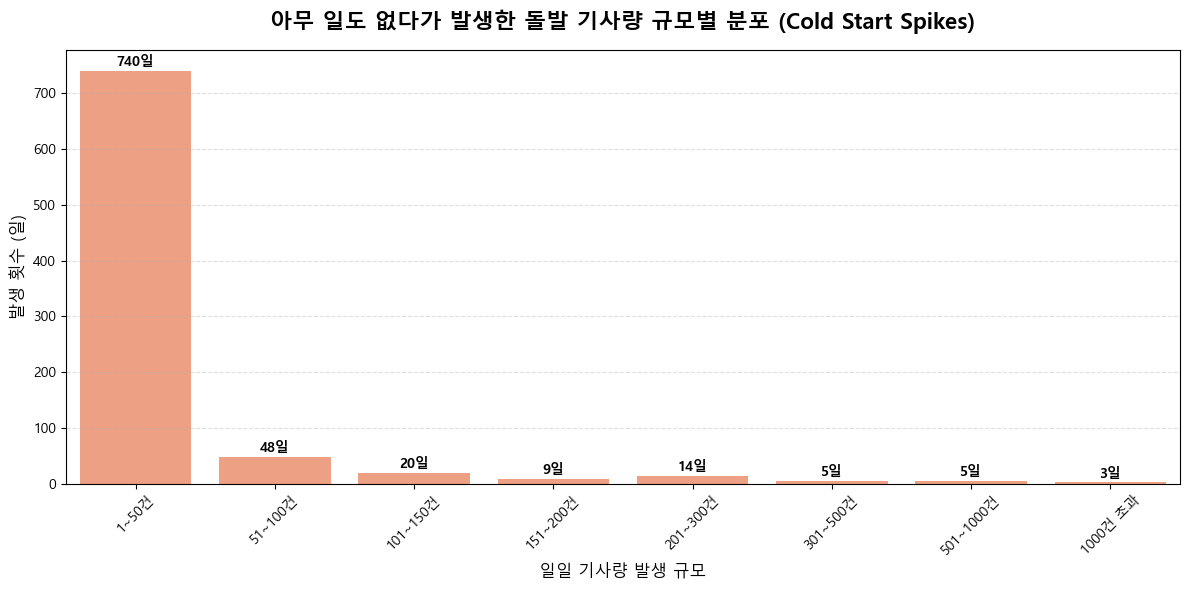

In [52]:
# 1. '0건 -> N건'으로 폭증한 데이터만 필터링 (이전 코드의 df_fill 사용)
inf_spikes = df_fill[df_fill['GrowthRate'] == np.inf].copy()

# 가장 크게 터진 날의 기사량 확인
max_volume = inf_spikes['NumMentions'].max()
print(f" 정적을 깨고 발생한 최대 일일 기사량: {max_volume}건\n")

# 2. 기사량(NumMentions) 구간(Bins) 및 라벨 설정
# 필요에 따라 구간을 더 잘게 쪼개거나 늘리셔도 됩니다.
bins = [0, 50, 100, 150, 200, 300, 500, 1000, np.inf]
labels = ['1~50건', '51~100건', '101~150건', '151~200건', '201~300건', '301~500건', '501~1000건', '1000건 초과']

# 3. pd.cut을 이용해 기사량을 지정한 구간으로 분류
inf_spikes['Volume_Group'] = pd.cut(inf_spikes['NumMentions'], bins=bins, labels=labels, right=True)

# 4. 구간별 통계 집계 (발생 일수 및 전체 대비 비율)
volume_stats = inf_spikes.groupby('Volume_Group', observed=False).size().reset_index(name='발생 일수(Days)')
volume_stats['비율(%)'] = (volume_stats['발생 일수(Days)'] / volume_stats['발생 일수(Days)'].sum() * 100).round(1)

print("--- 정적(0건)을 깨고 발생한 돌발 사건의 규모별 분포 ---")
display(volume_stats)

# 5. 결과를 직관적으로 보여주는 바 차트 시각화
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=volume_stats, x='Volume_Group', y='발생 일수(Days)', color='coral', alpha=0.8)

# 막대 위에 수치 텍스트 달기
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2., height + 3, f'{int(height)}일', ha='center', va='bottom', fontweight='bold')

plt.title('아무 일도 없다가 발생한 돌발 기사량 규모별 분포 (Cold Start Spikes)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('일일 기사량 발생 규모', fontsize=12)
plt.ylabel('발생 횟수 (일)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

--- 돌발 사건(Cold Start) 전후 패턴 분석 ---
조건: 어제 50건 이하 → 오늘 100건 이상 폭증
총 발생 횟수: 166번
  ├─ 단발성 (내일 다시 잠잠해짐): 108번 (65.1%)
  └─ 지속성 (내일도 이슈가 이어짐): 58번 (34.9%)



C:\Users\Jua\AppData\Local\Temp\ipykernel_57904\110464568.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_df = sudden_spikes.groupby(['Spike_Size', 'Is_OneDay_Wonder']).size().unstack(fill_value=0)


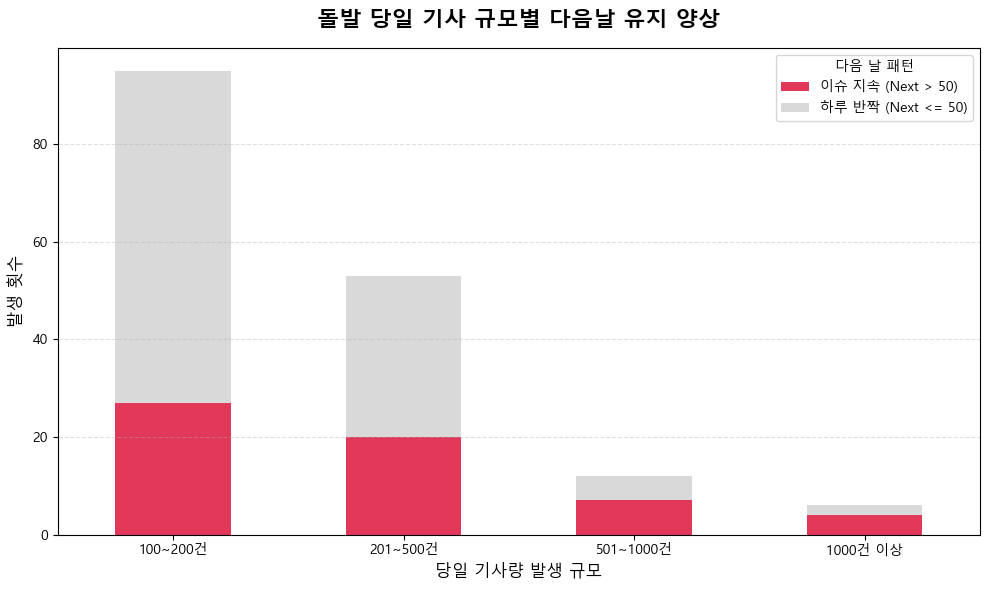

In [53]:
# 기초 데이터 (기사가 없는 날도 모두 0으로 꽉 채워진 전체 캘린더 생성)
# (이미 df_fill을 만드셨다면 이 부분은 생략 가능합니다)
daily_counts = df.groupby('SQLDATE')['NumMentions'].sum().reset_index().sort_values('SQLDATE')
all_dates = pd.date_range(start=daily_counts['SQLDATE'].min(), end=daily_counts['SQLDATE'].max())
df_fill = daily_counts.set_index('SQLDATE').reindex(all_dates).fillna(0).reset_index()
df_fill.columns = ['SQLDATE', 'NumMentions']

# 핵심: 어제, 오늘, 내일 기사량을 한 행에서 비교하기 위한 시프트(Shift)
df_fill['PrevMentions'] = df_fill['NumMentions'].shift(1)   # 어제 기사량
df_fill['NextMentions'] = df_fill['NumMentions'].shift(-1)  # 내일 기사량

# 분석 기준 설정 (자유롭게 변경 가능)
QUIET_THRESHOLD = 50   # '잠잠하다'의 기준 (0~50건)
SPIKE_THRESHOLD = 100  # '크게 터졌다'의 기준 (100건 이상)

# 패턴 조건 필터링
# 조건 A: 어제는 50건 이하였다.
cond_was_quiet = df_fill['PrevMentions'] <= QUIET_THRESHOLD
# 조건 B: 오늘은 100건 이상으로 폭발했다.
cond_spike_today = df_fill['NumMentions'] >= SPIKE_THRESHOLD

# 이 두 조건을 동시에 만족하는 날짜만 추출 ("잠잠하다가 터진 날")
sudden_spikes = df_fill[cond_was_quiet & cond_spike_today].copy()

# 터진 이후의 양상 분석 (하루 반짝? vs 이슈 지속?)
# 다음 날 다시 50건 이하로 떨어지면 True(하루 반짝), 아니면 False(지속)
sudden_spikes['Is_OneDay_Wonder'] = sudden_spikes['NextMentions'] <= QUIET_THRESHOLD

# 텍스트 통계 출력
total_sudden = len(sudden_spikes)
oneday_wonders = sudden_spikes['Is_OneDay_Wonder'].sum()
sustained = total_sudden - oneday_wonders

print(f"--- 돌발 사건(Cold Start) 전후 패턴 분석 ---")
print(f"조건: 어제 {QUIET_THRESHOLD}건 이하 → 오늘 {SPIKE_THRESHOLD}건 이상 폭증")
print(f"총 발생 횟수: {total_sudden}번")
if total_sudden > 0:
    print(f"  ├─ 단발성 (내일 다시 잠잠해짐): {oneday_wonders}번 ({(oneday_wonders/total_sudden*100):.1f}%)")
    print(f"  └─ 지속성 (내일도 이슈가 이어짐): {sustained}번 ({(sustained/total_sudden*100):.1f}%)\n")

# 8. 심층 분석 시각화: '터진 규모'별로 단발/지속 양상이 다를까?
if total_sudden > 0:
    # 당일 폭발 규모에 따라 구간을 나눔
    bins = [SPIKE_THRESHOLD - 1, 200, 500, 1000, np.inf]
    labels = [f'{SPIKE_THRESHOLD}~200건', '201~500건', '501~1000건', '1000건 이상']
    sudden_spikes['Spike_Size'] = pd.cut(sudden_spikes['NumMentions'], bins=bins, labels=labels)

    # 규모 및 지속성 여부로 그룹화
    summary_df = sudden_spikes.groupby(['Spike_Size', 'Is_OneDay_Wonder']).size().unstack(fill_value=0)
    # 컬럼명 직관적으로 변경
    if False in summary_df.columns:
        summary_df.rename(columns={False: '이슈 지속 (Next > 50)'}, inplace=True)
    if True in summary_df.columns:
        summary_df.rename(columns={True: '하루 반짝 (Next <= 50)'}, inplace=True)

    # 누적 막대 그래프(Stacked Bar) 시각화
    plt.figure(figsize=(10, 6))
    summary_df.plot(kind='bar', stacked=True, color=['crimson', 'lightgray'], ax=plt.gca(), alpha=0.85)
    
    plt.title('돌발 당일 기사 규모별 다음날 유지 양상', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('당일 기사량 발생 규모', fontsize=12)
    plt.ylabel('발생 횟수', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title='다음 날 패턴', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()

In [54]:
# 1. 30일 이동평균과 표준편차 계산
daily_vol['MA30'] = daily_vol['NumMentions'].rolling(window=30).mean()
daily_vol['STD30'] = daily_vol['NumMentions'].rolling(window=30).std()

# 2. Z-Score 산출: (오늘 기사량 - 30일 평균) / 30일 표준편차
daily_vol['ZScore'] = (daily_vol['NumMentions'] - daily_vol['MA30']) / daily_vol['STD30']

# 3. 임계값 설정 (보통 Z-Score 2.0 이상이면 통계적으로 유의미한 급증으로 간주)
threshold_z = 2.0
surge_days = daily_vol[daily_vol['ZScore'] >= threshold_z]

In [55]:
# 전체 기사량의 하위 25% 지점 계산
min_volume = daily_vol['NumMentions'].quantile(0.25)

# 기사량이 최소 기준 이상인 날들 중에서만 상위 5% 증가율 산출
filtered_growth = daily_vol[daily_vol['NumMentions'] >= min_volume]
adjusted_stats = filtered_growth['GrowthRate'].describe(percentiles=[.95, .99])

print(f"조정된 상위 1% 임계값: {adjusted_stats['99%']:.1f}%")

조정된 상위 1% 임계값: 9182.7%


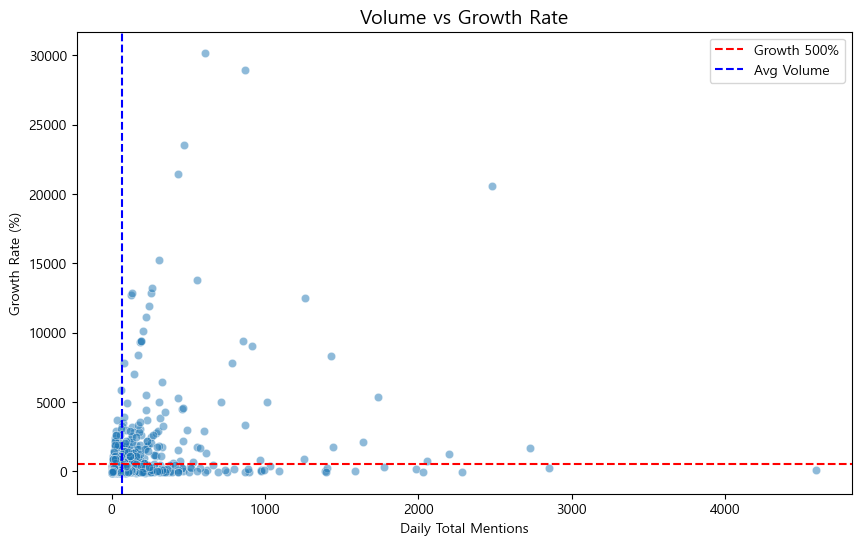

In [56]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=daily_vol, x='NumMentions', y='GrowthRate', alpha=0.5)

# 우측 상단(기사량도 많고 증가율도 높은 구역)이 핵심 타겟
plt.axhline(500, color='red', linestyle='--', label='Growth 500%') # 예시 임계선
plt.axvline(daily_vol['NumMentions'].mean(), color='blue', linestyle='--', label='Avg Volume')

plt.title('Volume vs Growth Rate', fontsize=14)
plt.xlabel('Daily Total Mentions')
plt.ylabel('Growth Rate (%)')
plt.legend()
plt.show()

In [57]:
# 데이터의 시작일과 종료일 확인
start_date = df['SQLDATE'].min()
end_date = df['SQLDATE'].max()

# 3. 시작일~종료일까지의 모든 날짜가 포함된 '전체 날짜 리스트' 생성
full_date_range = pd.date_range(start=start_date, end=end_date)

# 4. 데이터가 존재하는 고유 날짜 리스트 추출
existing_dates = pd.to_datetime(df['SQLDATE'].unique())

# 5. 전체 날짜에서 데이터가 있는 날짜를 제외하여 '누락된 날짜' 확인
missing_dates = full_date_range[~full_date_range.isin(existing_dates)]

# 6. 결과 출력
print(f"--- 🗓️ 전체 분석 기간: {start_date.date()} ~ {end_date.date()} ---")
print(f"총 분석 대상 일수: {len(full_date_range)}일")
print(f"데이터가 존재하는 일수: {len(existing_dates)}일")
print(f"⚠️ 기사가 한 건도 없는 날(누락일): {len(missing_dates)}일")

# 7. 누락된 날짜 상위 10개 예시 보기
if len(missing_dates) > 0:
    print("\n--- 🔇 기사가 없었던 날 리스트 (최근 10일) ---")
    print(missing_dates.sort_values(ascending=False)[:10].date)

--- 🗓️ 전체 분석 기간: 2013-04-01 ~ 2026-05-04 ---
총 분석 대상 일수: 4782일
데이터가 존재하는 일수: 2415일
⚠️ 기사가 한 건도 없는 날(누락일): 2367일

--- 🔇 기사가 없었던 날 리스트 (최근 10일) ---
[datetime.date(2026, 5, 3) datetime.date(2026, 5, 2)
 datetime.date(2026, 5, 1) datetime.date(2026, 4, 27)
 datetime.date(2026, 4, 26) datetime.date(2026, 4, 25)
 datetime.date(2026, 4, 22) datetime.date(2026, 4, 21)
 datetime.date(2026, 4, 20) datetime.date(2026, 4, 19)]



빈 날짜 채우기

In [58]:
# 1. 저장된 df를 날짜별로 집계
daily_all = df.groupby('SQLDATE')['NumMentions'].sum().reset_index()

# 2. 날짜 타입 일치시키기 (병합을 위한 필수 단계)
daily_all['SQLDATE'] = pd.to_datetime(daily_all['SQLDATE'])

# 3. 전체 분석 기간(달력) 생성 (4,782일)
all_dates = pd.date_range(start='2013-04-01', end='2026-05-04')
full_df = pd.DataFrame({'SQLDATE': all_dates})

# 4. 빈 달력에 이슈 데이터 병합 (데이터 없는 날은 NaN이 됨)
daily_all = pd.merge(full_df, daily_all, on='SQLDATE', how='left')

# 5. NaN(기사가 없던 날)을 0으로 채우기 (침묵의 시간을 복구!)
daily_all['NumMentions'] = daily_all['NumMentions'].fillna(0)

# 6. 연도 정보 및 이동평균 다시 계산
daily_all['Year'] = daily_all['SQLDATE'].dt.year
daily_all['MA30'] = daily_all['NumMentions'].rolling(window=30, min_periods=1).mean()

# 7. 최종 검증
print(f"--- 🔍 데이터 복구 확인 ---")
print(f"전체 일수: {len(daily_all)}일 (4782가 나와야 함)")
print(f"기사가 0건인 날: {(daily_all['NumMentions'] == 0).sum()}일 (2367이 나와야 함)")

--- 🔍 데이터 복구 확인 ---
전체 일수: 4782일 (4782가 나와야 함)
기사가 0건인 날: 2367일 (2367이 나와야 함)


In [17]:
print(df['SQLDATE'].nunique())

2415


상위 분위수(Quantile)를 이용한 기준점 찾기

In [59]:
# 1. 기사량 분포의 분위수 계산
quantiles = [0.5, 0.75, 0.9, 0.95, 0.99]
q_values = daily_all['NumMentions'].quantile(quantiles)

print("--- 기사량 구간별 기준치 ---")
for q, val in zip(quantiles, q_values):
    print(f"상위 {int((1-q)*100):>2}% 지점: 최소 {int(val):>4}건 이상")

--- 기사량 구간별 기준치 ---
상위 50% 지점: 최소    1건 이상
상위 25% 지점: 최소   15건 이상
상위  9% 지점: 최소   55건 이상
상위  5% 지점: 최소  127건 이상
상위  1% 지점: 최소  562건 이상


최소 기사량(Floor)을 적용한 데이터 필터링

In [19]:
# 1. 비교할 임계값 리스트
thresholds = [50, 100, 150, 200]
comparison_results = []

for t in thresholds:
    # 해당 기준을 통과한 날들
    passed_days = daily_all[daily_all['NumMentions'] >= t].copy()
    
    # 통계 계산
    total_days = len(passed_days)
    yearly_avg = total_days / (len(daily_all) / 365.25) # 연평균 촬영 횟수
    avg_mentions = passed_days['NumMentions'].mean()
    
    comparison_results.append({
        "최소 기준(Floor)": f"{t}건 이상",
        "해당 일수(Total)": f"{total_days}일",
        "연평균 촬영 횟수": f"약 {yearly_avg:.1f}회",
        "필터링 후 평균 기사량": f"{int(avg_mentions)}건",
        "전체 데이터 대비 비중": f"{(total_days / len(daily_all) * 100):.1f}%"
    })

# 2. 결과 출력 (데이터프레임 형태)
df_comp = pd.DataFrame(comparison_results)
print("---  위성 촬영 가동률 시뮬레이션 결과 ---")
display(df_comp)

---  위성 촬영 가동률 시뮬레이션 결과 ---


,최소 기준(Floor),해당 일수(Total),연평균 촬영 횟수,필터링 후 평균 기사량,전체 데이터 대비 비중
0,50건 이상,514일,약 39.3회,255건,10.7%
1,100건 이상,300일,약 22.9회,387건,6.3%
2,150건 이상,206일,약 15.7회,508건,4.3%
3,200건 이상,154일,약 11.8회,623건,3.2%


0건 포함 증가율(Log Growth) 분포 분석

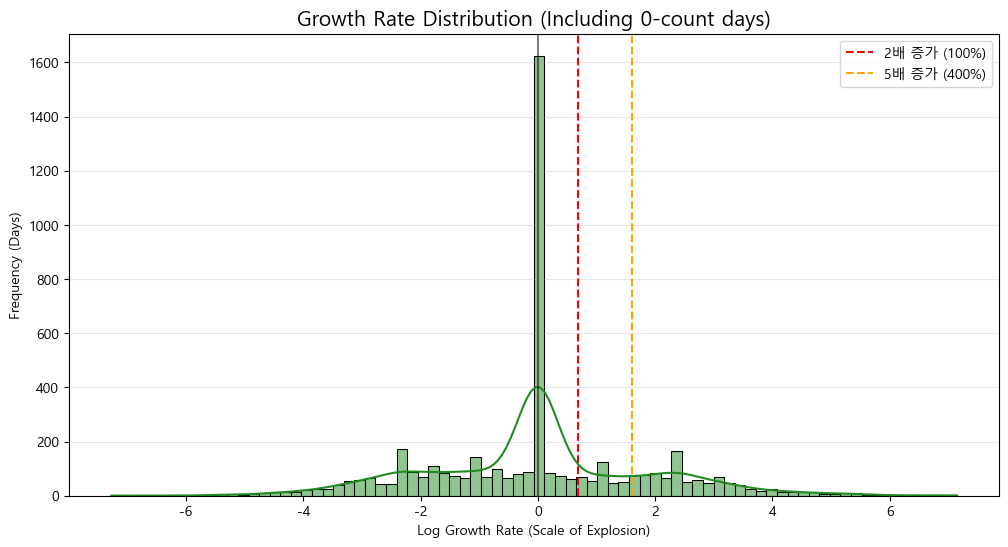

In [20]:
# 1. 로그 성장률 계산 (Log Difference)
# log(오늘+1) - log(어제+1) 을 통해 0건인 날도 안전하게 계산합니다.
daily_all['LogGrowth'] = np.log1p(daily_all['NumMentions']).diff()

# 2. 분포 시각화
plt.figure(figsize=(12, 6))

# 히스토그램
sns.histplot(daily_all['LogGrowth'].dropna(), bins=80, kde=True, color='forestgreen')

# 시각적 가이드라인
plt.axvline(0, color='black', linestyle='-', alpha=0.5) # 변화 없음
plt.axvline(np.log(2), color='red', linestyle='--', label='2배 증가 (100%)')
plt.axvline(np.log(5), color='orange', linestyle='--', label='5배 증가 (400%)')

plt.title('Growth Rate Distribution (Including 0-count days)', fontsize=15)
plt.xlabel('Log Growth Rate (Scale of Explosion)')
plt.ylabel('Frequency (Days)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [21]:
# 상태 분류 함수
def get_state(x):
    if x == 0: return 'Silence (0)'
    elif x < 50: return 'Noise (1~49)'
    else: return 'Event (50+)'

daily_all['State'] = daily_all['NumMentions'].apply(get_state)
daily_all['Prev_State'] = daily_all['State'].shift(1)

# 전이 행렬 (Transition Matrix) 계산
transition = pd.crosstab(daily_all['Prev_State'], daily_all['State'], normalize='index') * 100

print("--- 전일 대비 상태 변화 확률 (%) ---")
display(transition.round(1))

--- 전일 대비 상태 변화 확률 (%) ---


State,Event (50+),Noise (1~49),Silence (0)
Prev_State,,,
Event (50+),38.1,48.1,13.8
Noise (1~49),11.1,48.3,40.7
Silence (0),4.6,31.1,64.3


In [60]:
# 상태 분류 함수
def get_state(x):
    if x == 0: return 'Silence (0)'
    elif x < 100: return 'Noise (1~100)'
    else: return 'Event (100+)'

daily_all['State'] = daily_all['NumMentions'].apply(get_state)
daily_all['Prev_State'] = daily_all['State'].shift(1)

# 전이 행렬 (Transition Matrix) 계산
transition = pd.crosstab(daily_all['Prev_State'], daily_all['State'], normalize='index') * 100

print("--- 전일 대비 상태 변화 확률 (%) ---")
display(transition.round(1))

--- 전일 대비 상태 변화 확률 (%) ---


State,Event (100+),Noise (1~100),Silence (0)
Prev_State,,,
Event (100+),36.0,55.0,9.0
Noise (1~100),6.4,55.0,38.6
Silence (0),2.4,33.2,64.3


In [22]:
# 1. 비교할 기준 리스트
floors = [50, 100, 150, 200]

print(f"{'최소 기준':<10} | {'총 이벤트 일수':<12} | {'연평균 촬영 횟수':<15}")
print("-" * 45)

for f in floors:
    event_days = daily_all[daily_all['NumMentions'] >= f]
    total_count = len(event_days)
    # 전체 기간(4,782일)을 연 단위로 환산하여 계산
    yearly_avg = total_count / (4782 / 365.25)
    
    print(f"{f:>4}건 이상  | {total_count:>8}일      | 약 {yearly_avg:>4.1f}회")

최소 기준      | 총 이벤트 일수     | 연평균 촬영 횟수      
---------------------------------------------
  50건 이상  |      514일      | 약 39.3회
 100건 이상  |      300일      | 약 22.9회
 150건 이상  |      206일      | 약 15.7회
 200건 이상  |      154일      | 약 11.8회


In [23]:
# 기준을 100건으로 변경하여 상태 재분류
def get_state_100(x):
    if x == 0: return 'Silence (0)'
    elif x < 100: return 'Noise (1~99)'
    else: return 'Event (100+)'

daily_all['State_100'] = daily_all['NumMentions'].apply(get_state_100)
daily_all['Prev_State_100'] = daily_all['State_100'].shift(1)

# 전이 행렬 계산
transition_100 = pd.crosstab(daily_all['Prev_State_100'], daily_all['State_100'], normalize='index') * 100
display(transition_100.round(1))

State_100,Event (100+),Noise (1~99),Silence (0)
Prev_State_100,,,
Event (100+),36.0,55.0,9.0
Noise (1~99),6.4,55.0,38.6
Silence (0),2.4,33.2,64.3


톤과 기사량의 관계

In [62]:
# 1. 집계 시 AvgTone을 포함 (기사량은 합계, 톤은 평균)
daily_all = df.groupby('SQLDATE').agg({
    'NumMentions': 'sum',
    'AvgTone': 'mean'
}).reset_index()

# 2. 아까 했던 '빈 날짜 채우기' 다시 적용 (전체 달력 유지)
all_dates = pd.date_range(start='2013-04-01', end='2026-05-04')
full_df = pd.DataFrame({'SQLDATE': all_dates})
daily_all = pd.merge(full_df, daily_all, on='SQLDATE', how='left')

# 3. 누락된 값 처리
daily_all['NumMentions'] = daily_all['NumMentions'].fillna(0)
# 기사가 없는 날은 톤을 0(중립)으로 채우거나 그대로 NaN으로 둡니다.
daily_all['AvgTone'] = daily_all['AvgTone'].fillna(0)

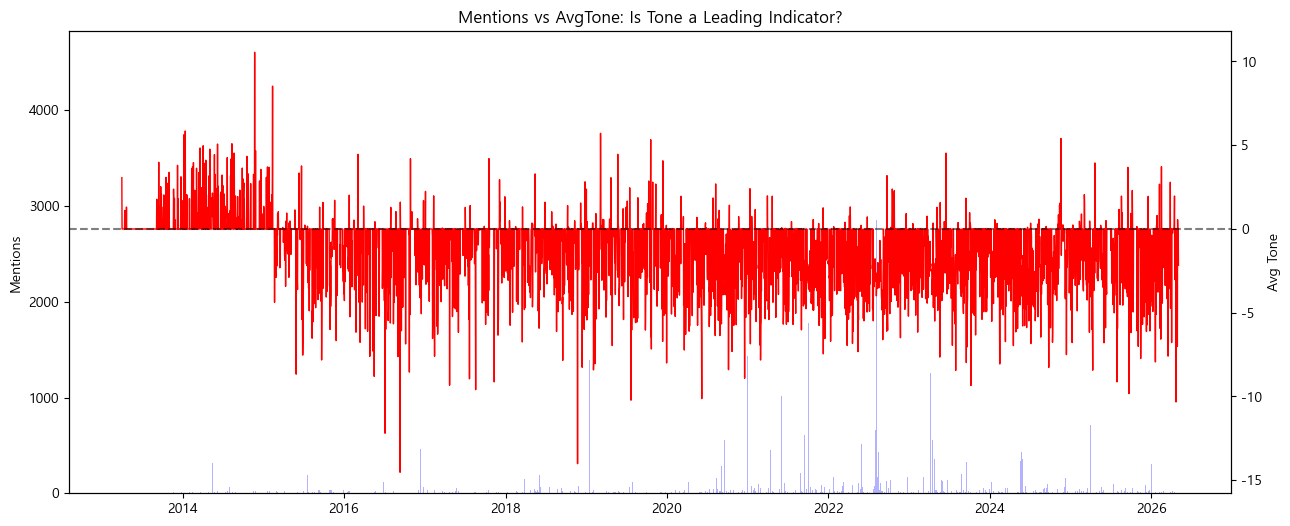

기사량과 톤의 상관계수: -0.1396


In [64]:
# 1. 일별 평균 톤 계산
# daily_all = df.groupby('SQLDATE').agg({'NumMentions':'sum', 'AvgTone':'mean'}).reset_index()

fig, ax1 = plt.subplots(figsize=(15, 6))

# 기사량 (Bar)
ax1.bar(daily_all['SQLDATE'], daily_all['NumMentions'], color='blue', alpha=0.3, label='Mentions')
ax1.set_ylabel('Mentions')

# 평균 톤 (Line)
ax2 = ax1.twinx()
ax2.plot(daily_all['SQLDATE'], daily_all['AvgTone'], color='red', linewidth=1, label='Avg Tone')
ax2.axhline(0, color='black', linestyle='--', alpha=0.5) # 0선(중립)
ax2.set_ylabel('Avg Tone')

plt.title('Mentions vs AvgTone: Is Tone a Leading Indicator?')
plt.show()

# 톤과 기사량의 상관계수 확인
correlation = daily_all['NumMentions'].corr(daily_all['AvgTone'])
print(f"기사량과 톤의 상관계수: {correlation:.4f}")

C:\Users\Jua\AppData\Local\Temp\ipykernel_57904\2520244795.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


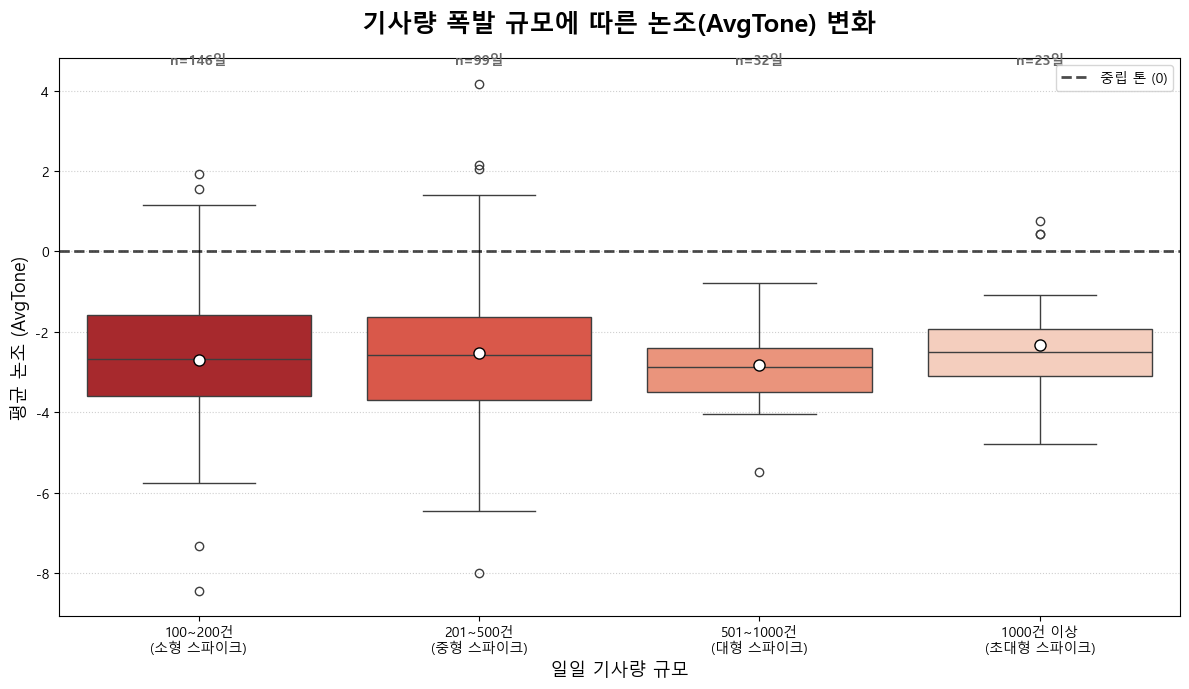

In [67]:
# 1. 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 기사량이 100건 이상인 날만 필터링
spike_days = daily_all[daily_all['NumMentions'] >= 100].copy()

# 3. 기사량 규모에 따라 구간(Bin) 나누기
# 데이터의 최대치에 따라 bins 기준은 유동적으로 조절 가능
max_mention = spike_days['NumMentions'].max()
bins = [99, 200, 500, 1000, max_mention + 1]
labels = ['100~200건\n(소형 스파이크)', '201~500건\n(중형 스파이크)', '501~1000건\n(대형 스파이크)', '1000건 이상\n(초대형 스파이크)']

spike_days['Mention_Group'] = pd.cut(spike_days['NumMentions'], bins=bins, labels=labels)

# 4. 시각화: 규모별 논조 분포 (Boxplot)
plt.figure(figsize=(12, 7))

# 박스플롯: 규모가 커질수록 색상이 진해지도록 팔레트 설정 (Reds_r: 붉은색 역순)
sns.boxplot(
    data=spike_days, 
    x='Mention_Group', 
    y='AvgTone', 
    palette='Reds_r',
    showmeans=True, # 평균값을 마커로 표시
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

# 0선 (중립) 강조
plt.axhline(0, color='black', linestyle='--', linewidth=2, alpha=0.7, label='중립 톤 (0)')

# 각 구간별 데이터 개수(N)를 그래프 위에 표시
group_counts = spike_days['Mention_Group'].value_counts().sort_index()
for i, count in enumerate(group_counts):
    plt.text(i, spike_days['AvgTone'].max() + 0.5, f'n={count}일', ha='center', fontweight='bold', color='dimgray')

plt.title('기사량 폭발 규모에 따른 논조(AvgTone) 변화', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('일일 기사량 규모', fontsize=13)
plt.ylabel('평균 논조 (AvgTone)', fontsize=13)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [72]:
# 1. 날짜별로 톤의 평균과 표준편차를 동시에 계산
tone_reliability = df.groupby('SQLDATE')['AvgTone'].agg(['mean', 'std', 'count']).reset_index()

# 2. '합의 지수(Consensus Index)' 생성
# 톤은 낮을수록(부정적), 표준편차는 작을수록(의견 일치) 점수가 높게 설계
# (std + 1)로 나누어 분모가 0이 되는 것을 방지
tone_reliability['ConsensusScore'] = abs(tone_reliability['mean']) / (tone_reliability['std'] + 1)

# 3. 기사량이 100건 이상이면서 의견도 일치하는(부정적으로) 날들 추출
reliable_threats = tone_reliability[
    (tone_reliability['count'] >= 100) & 
    (tone_reliability['mean'] <= -2)
].sort_values(by='ConsensusScore', ascending=False)

display(reliable_threats.head(10))

,SQLDATE,mean,std,count,ConsensusScore
1519,2022-08-04,-2.999587,1.332166,153,1.286181
1695,2023-04-10,-2.494734,1.198471,114,1.134759


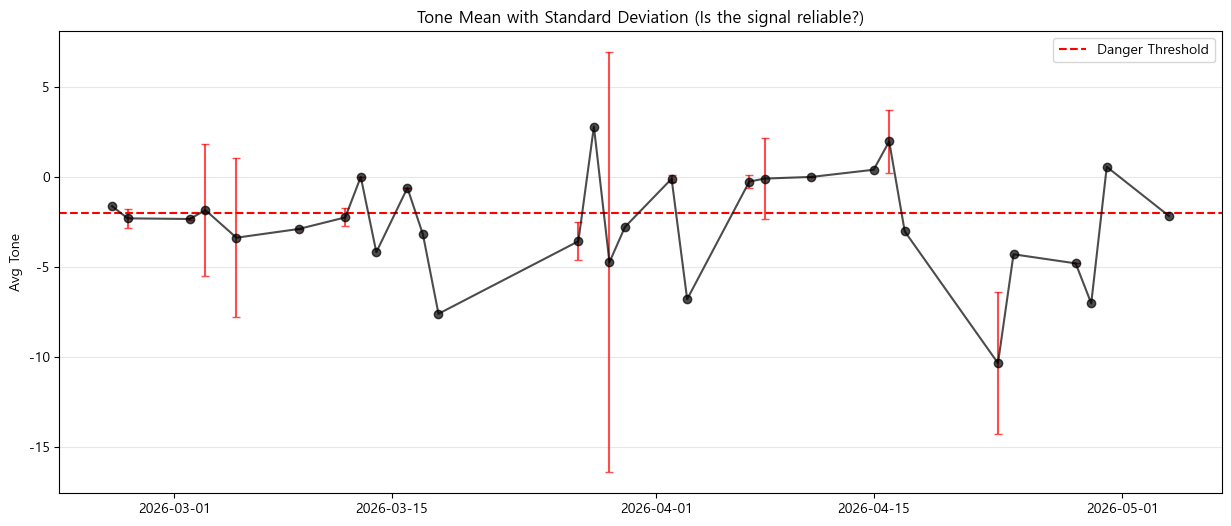

In [27]:
import matplotlib.pyplot as plt

# 최근 30일 데이터로 예시 시각화
sample = tone_reliability.tail(30)

plt.figure(figsize=(15, 6))
plt.errorbar(sample['SQLDATE'], sample['mean'], yerr=sample['std'], 
             fmt='o', ecolor='red', capsize=3, linestyle='-', color='black', alpha=0.7)

plt.axhline(-2, color='red', linestyle='--', label='Danger Threshold')
plt.title('Tone Mean with Standard Deviation (Is the signal reliable?)')
plt.ylabel('Avg Tone')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

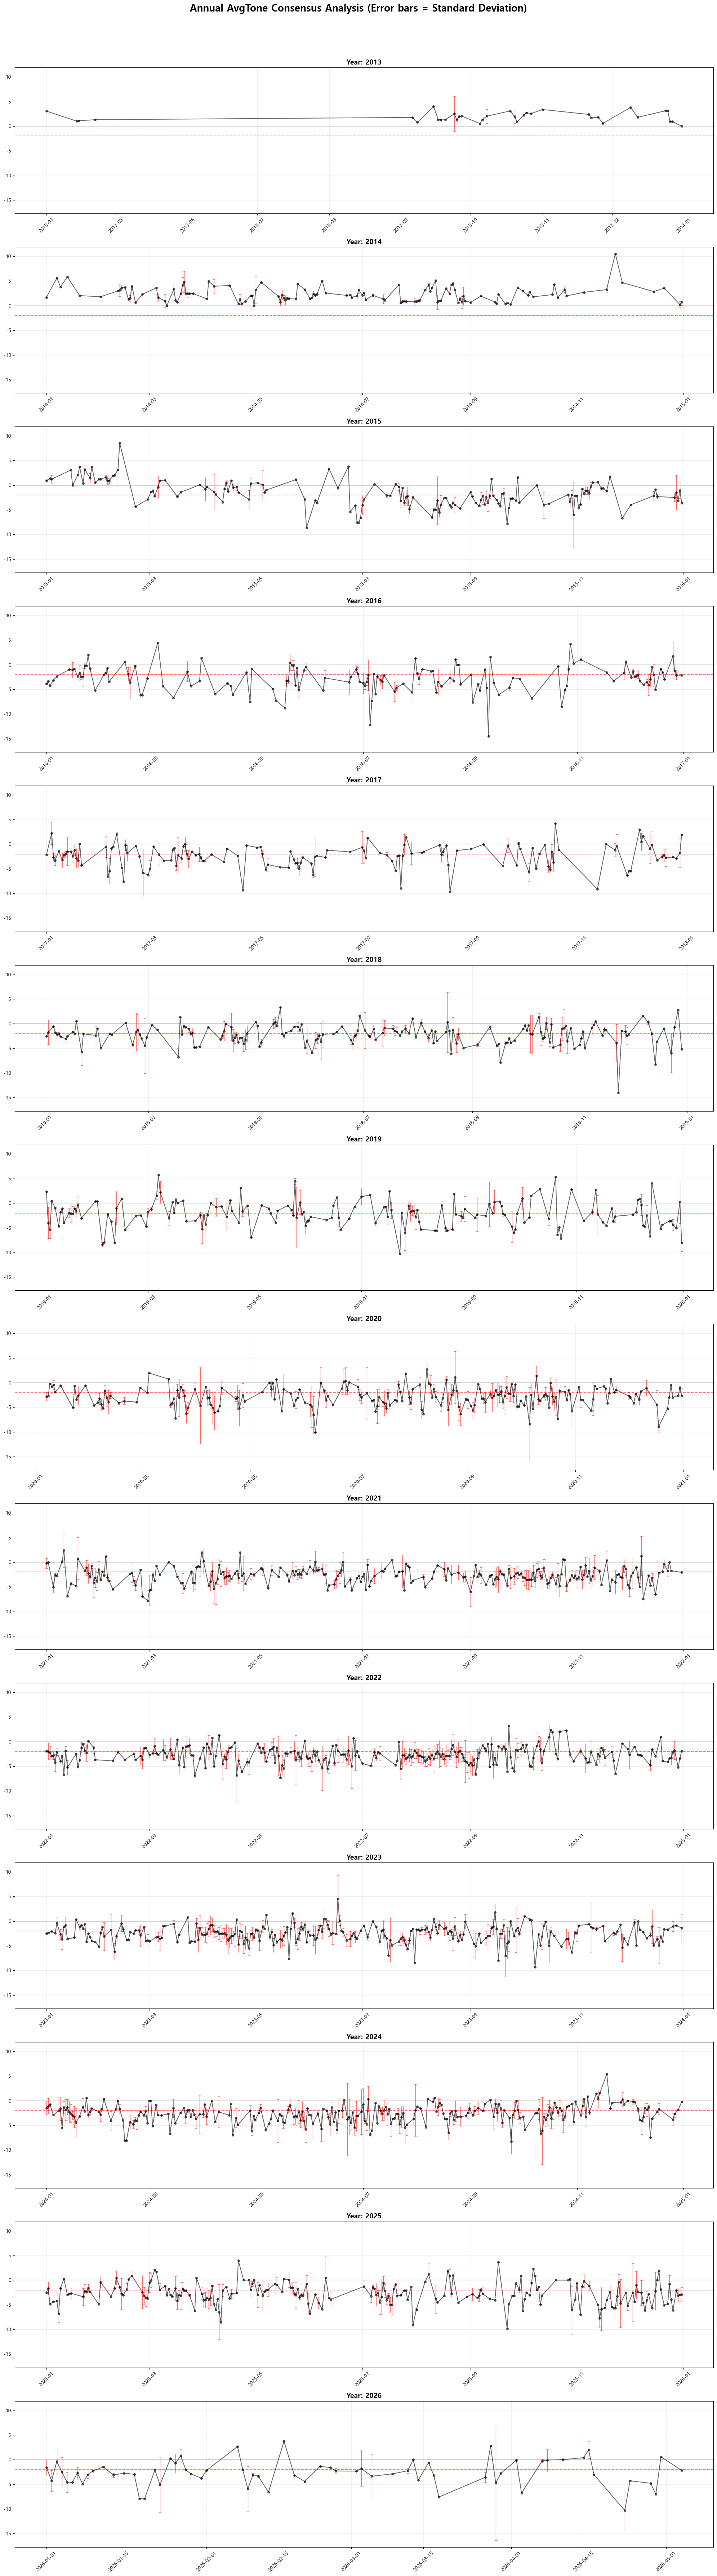

In [28]:
import math

# 1. 연도 정보 추출
tone_reliability['Year'] = tone_reliability['SQLDATE'].dt.year
years = sorted(tone_reliability['Year'].unique())

# 2. 서브플롯 배치 설정
cols = 1
rows = math.ceil(len(years) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 5), sharey=True)
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    # 해당 연도 데이터 필터링
    yearly_data = tone_reliability[tone_reliability['Year'] == year]
    
    # 에러바 플롯 (기사가 너무 적은 날은 노이즈 방지를 위해 투명도 조절 가능)
    ax.errorbar(yearly_data['SQLDATE'], yearly_data['mean'], yerr=yearly_data['std'], 
                fmt='o', ecolor='red', capsize=2, linestyle='-', color='black', 
                alpha=0.6, markersize=4, elinewidth=1)
    
    # 기준선 및 설정
    ax.axhline(-2, color='red', linestyle='--', alpha=0.5)
    ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
    ax.set_title(f'Year: {year}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.2)
    
    # X축 날짜 포맷 최적화 (연도별로 월/일만 보이게)
    ax.tick_params(axis='x', rotation=45)

# 남는 서브플롯 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Annual AvgTone Consensus Analysis (Error bars = Standard Deviation)', 
             fontsize=20, y=1.02, fontweight='bold')
plt.show()

In [29]:
# 1. 좌표(위도, 경도)별로 그룹화하여 기사 수(count)와 톤 평균(mean) 계산
# ActionGeo_Lat, ActionGeo_Long 컬럼을 사용합니다.
location_stats = df.groupby(['ActionGeo_Lat', 'ActionGeo_Long']).agg({
    'AvgTone': 'mean',
    'SQLDATE': 'count'  # 기사 수를 세기 위해 SQLDATE 사용
}).reset_index()

# 2. 컬럼명 변경
location_stats.columns = ['Latitude', 'Longitude', 'AvgTone_Mean', 'Article_Count']

# 3. 기사 수(Article_Count) 기준 내림차순 정렬 후 상위 10개 추출
top_15_locations = location_stats.sort_values(by='Article_Count', ascending=False).head(15)

# 4. 결과 출력
print("--- 📍 좌표별 기사 수 상위 15위 및 평균 톤 ---")
display(top_15_locations)

--- 📍 좌표별 기사 수 상위 15위 및 평균 톤 ---


,Latitude,Longitude,AvgTone_Mean,Article_Count
513,39.9289,116.3880,-2.710309,3899
266,25.0478,121.5320,-2.335379,2783
186,24.0000,119.0000,-2.452130,722
187,24.0000,121.0000,-2.344338,387
197,24.1098,113.0050,-2.956425,381
497,38.8951,-77.0364,-2.781496,342
219,24.4367,118.3180,-3.278178,340
381,31.2222,121.4580,-1.251593,145
530,41.0000,123.0000,-2.705174,104
75,21.4167,121.5000,-1.758297,99


1. 중국 베이징 (중남해 인근) -2.710309(4)
2. 대만 타이베이 (총통부 인근) -2.335379(12)
3. 대만 해협 (중간선 인근)  -2.452130(9)
4. 대만 본섬 중심부 (난터우)  -2.344338(12)
5. 중국 광둥성 칭위안  -2.956425(2)
6. 미국 워싱턴 D.C. (백악관)   -2.781496(3)
7. 진먼다오 (금문도)   -3.278178(1)
8. 중국 상하이   -1.251593(15)
9. 중국 랴오닝성 안산/랴오양   -2.705174(5)
10. 바시 해협 (대만 남단)   -1.758297(14)
11. 대만 타오위안 (국제공항 인근)    -2.673153(6)
12. 남중국해 (중심부)     -2.594895(7)
13. 대만 타오위안 (해안/공업지대)    -2.432191(11)
14. 일본 도쿄 (황거/정부청사 인근)    -2.450660(10)
15. 중국 푸젠성 (싼밍 인근)    -2.550922(8)

사건을 언급하는 주체의 위치와 사건의 발생지 혼재함...

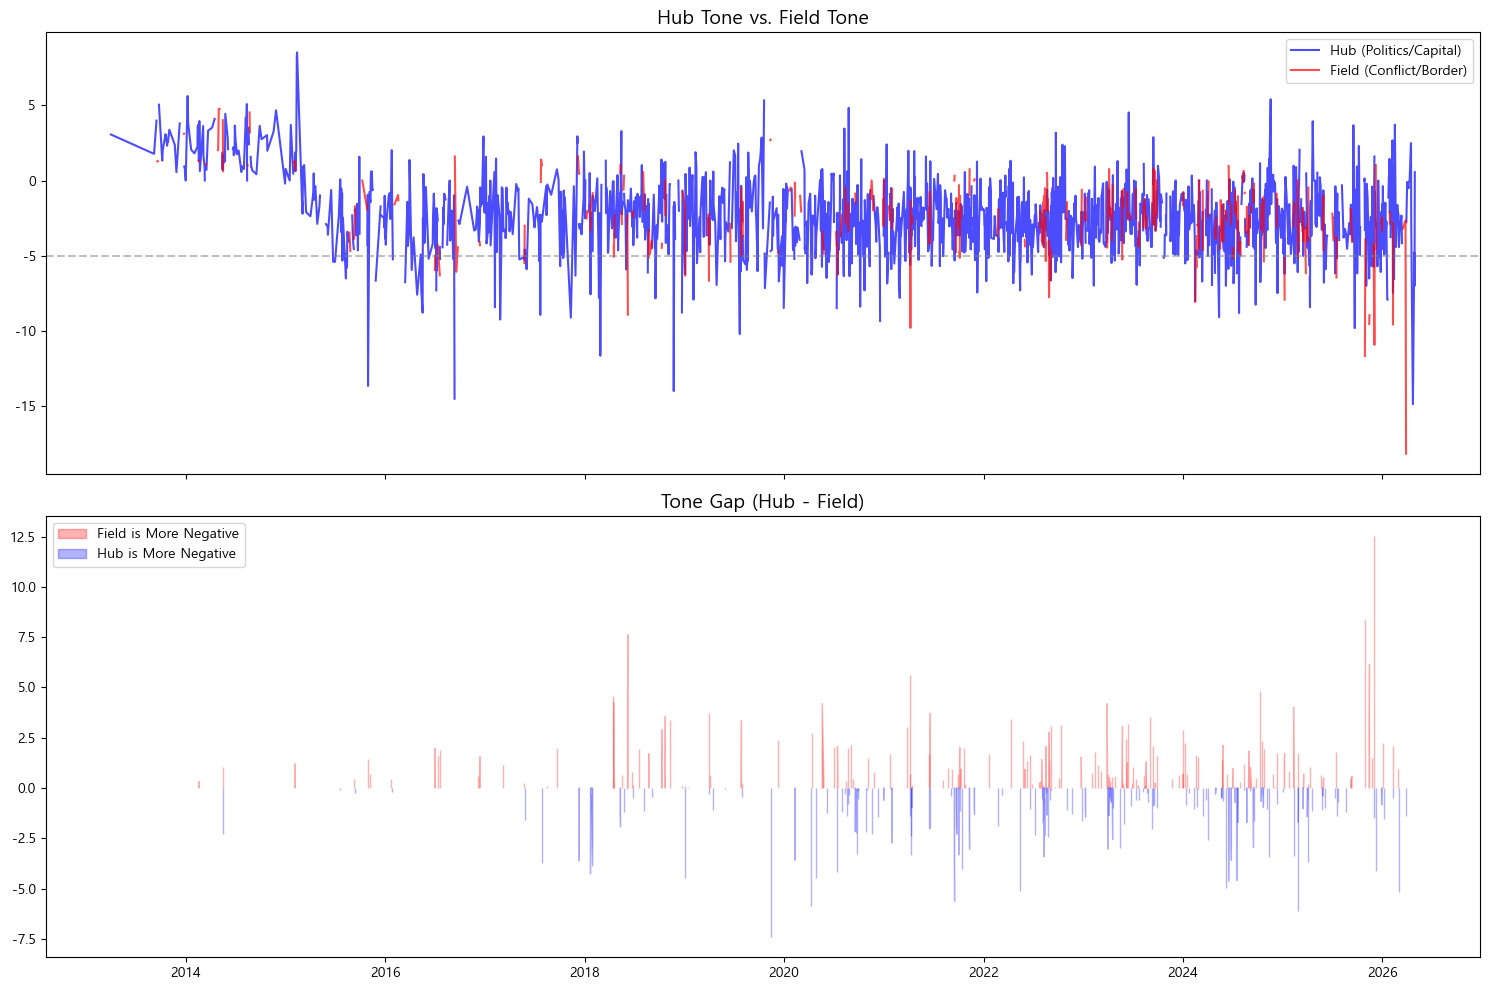

In [30]:
# 1. 좌표 그룹 정의
def classify_location(lat, lon):
    # 관측소(Narrative Hubs): 주요 수도 및 정책 결정지
    hubs = [
        (39.9289, 116.3880), # 베이징
        (25.0478, 121.5320), # 타이베이
        (38.8951, -77.0364), # 워싱턴 DC
        (35.6850, 139.7510)  # 도쿄
    ]
    # 현장(Action Sensors): 분쟁 접경지 및 해상 요충지
    fields = [
        (24.0000, 119.0000), # 대만 해협
        (24.4367, 118.3180), # 진먼다오
        (21.4167, 121.5000), # 바시 해협
        (15.0000, 115.0000), # 남중국해
        (26.5450, 117.8430)  # 푸젠성 내륙 기지
    ]
    
    if (lat, lon) in hubs: return 'Hub (Narrative)'
    if (lat, lon) in fields: return 'Field (Action)'
    return 'Others'

# 2. 그룹 할당 및 일별 톤 평균 계산
df['LocGroup'] = df.apply(lambda x: classify_location(x['ActionGeo_Lat'], x['ActionGeo_Long']), axis=1)
daily_groups = df[df['LocGroup'] != 'Others'].groupby(['SQLDATE', 'LocGroup'])['AvgTone'].mean().unstack()

# 3. 톤 격차(Gap) 계산: 관측소와 현장의 온도 차이
daily_groups['Tone_Gap'] = daily_groups['Hub (Narrative)'] - daily_groups['Field (Action)']

# 4. 시각화
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# (위) 두 그룹의 톤 추이 비교
ax1.plot(daily_groups.index, daily_groups['Hub (Narrative)'], label='Hub (Politics/Capital)', color='blue', alpha=0.7)
ax1.plot(daily_groups.index, daily_groups['Field (Action)'], label='Field (Conflict/Border)', color='red', alpha=0.7)
ax1.axhline(-5, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Hub Tone vs. Field Tone', fontsize=14)
ax1.legend()

# (아래) 톤 격차 (Divergence)
ax2.fill_between(daily_groups.index, daily_groups['Tone_Gap'], 0, 
                 where=(daily_groups['Tone_Gap'] >= 0), color='red', alpha=0.3, label='Field is More Negative')
ax2.fill_between(daily_groups.index, daily_groups['Tone_Gap'], 0, 
                 where=(daily_groups['Tone_Gap'] < 0), color='blue', alpha=0.3, label='Hub is More Negative')
ax2.set_title('Tone Gap (Hub - Field)', fontsize=14)
ax2.legend()

plt.tight_layout()
plt.show()

C:\Users\Jua\AppData\Local\Temp\ipykernel_57904\4267867693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_coords_sorted, x='AvgTone_Mean', y='Location_Name', palette=colors)


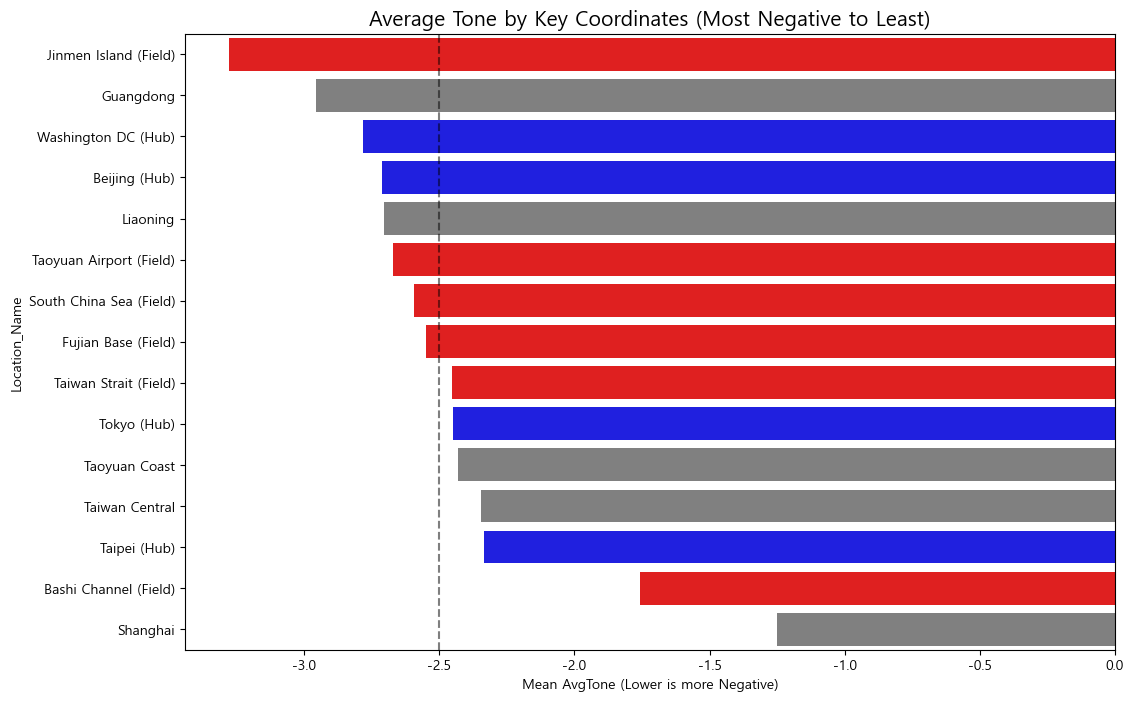

In [31]:
# 1. 주요 좌표 리스트와 명칭 매핑
location_map = {
    (39.9289, 116.3880): 'Beijing (Hub)',
    (25.0478, 121.5320): 'Taipei (Hub)',
    (38.8951, -77.0364): 'Washington DC (Hub)',
    (35.6850, 139.7510): 'Tokyo (Hub)',
    (24.4367, 118.3180): 'Jinmen Island (Field)',
    (24.0000, 119.0000): 'Taiwan Strait (Field)',
    (21.4167, 121.5000): 'Bashi Channel (Field)',
    (15.0000, 115.0000): 'South China Sea (Field)',
    (26.5450, 117.8430): 'Fujian Base (Field)',
    (25.0327, 121.2750): 'Taoyuan Airport (Field)',
    (31.2222, 121.4580): 'Shanghai',
    (24.0000, 121.0000): 'Taiwan Central',
    (24.1098, 113.0050): 'Guangdong',
    (41.0000, 123.0000): 'Liaoning',
    (25.0177, 121.1740): 'Taoyuan Coast'
}

# 2. 데이터 필터링 및 이름 붙이기
top_coords = location_stats[location_stats.apply(lambda x: (x['Latitude'], x['Longitude']) in location_map, axis=1)].copy()
top_coords['Location_Name'] = top_coords.apply(lambda x: location_map[(x['Latitude'], x['Longitude'])], axis=1)

# 3. 시각화 (평균 톤 기준 정렬)
plt.figure(figsize=(12, 8))
top_coords_sorted = top_coords.sort_values(by='AvgTone_Mean', ascending=True) # 낮은 순(부정적 순) 정렬

colors = ['red' if 'Field' in name else 'blue' if 'Hub' in name else 'gray' for name in top_coords_sorted['Location_Name']]

sns.barplot(data=top_coords_sorted, x='AvgTone_Mean', y='Location_Name', palette=colors)
plt.axvline(-2.5, color='black', linestyle='--', alpha=0.5) # 전체 평균 가이드선
plt.title('Average Tone by Key Coordinates (Most Negative to Least)', fontsize=15)
plt.xlabel('Mean AvgTone (Lower is more Negative)')
plt.show()

C:\Users\Jua\AppData\Local\Temp\ipykernel_57904\800171176.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=target_stats_sorted, x='std', y='Location_Name', palette='viridis')


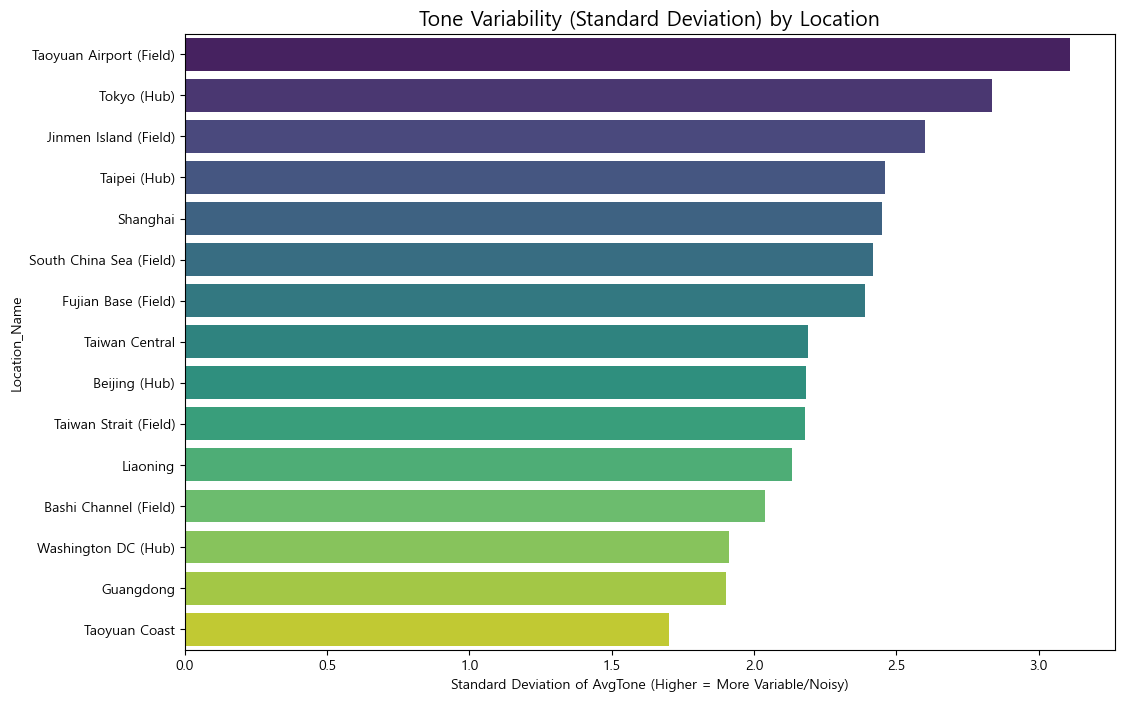

In [32]:
# 1. 좌표별로 톤의 평균(mean)과 표준편차(std) 계산
location_variability = df.groupby(['ActionGeo_Lat', 'ActionGeo_Long'])['AvgTone'].agg(['mean', 'std', 'count']).reset_index()

# 2. 분석관님이 지정한 15개 주요 좌표 필터링 및 이름 매핑
location_variability['Location_Name'] = location_variability.apply(
    lambda x: location_map.get((x['ActionGeo_Lat'], x['ActionGeo_Long']), 'Other'), axis=1
)
target_stats = location_variability[location_variability['Location_Name'] != 'Other'].copy()

# 3. 시각화 (표준편차 기준 정렬)
plt.figure(figsize=(12, 8))
target_stats_sorted = target_stats.sort_values(by='std', ascending=False) # 편차가 큰 순서대로

# 바 차트 그리기
sns.barplot(data=target_stats_sorted, x='std', y='Location_Name', palette='viridis')
plt.title('Tone Variability (Standard Deviation) by Location', fontsize=15)
plt.xlabel('Standard Deviation of AvgTone (Higher = More Variable/Noisy)')
plt.show()

In [33]:
# 1. 일별 좌표(위도, 경도 쌍) 개수 산출
daily_geo_diversity = df.groupby('SQLDATE').apply(
    lambda x: x[['ActionGeo_Lat', 'ActionGeo_Long']].drop_duplicates().shape[0]
).reset_index()

daily_geo_diversity.columns = ['SQLDATE', 'Unique_Coord_Count']

# 2. 기초 통계량 (최대, 최소, 평균) 확인
stats = {
    'Maximum': daily_geo_diversity['Unique_Coord_Count'].max(),
    'Minimum': daily_geo_diversity['Unique_Coord_Count'].min(),
    'Average': daily_geo_diversity['Unique_Coord_Count'].mean()
}

print("--- 일별 좌표 다양성 기초 통계 ---")
for key, value in stats.items():
    print(f"{key}: {value:.2f}")

# 3. 좌표가 가장 다양했던 날짜 TOP 15 추출
top_15_diverse_days = daily_geo_diversity.sort_values(by='Unique_Coord_Count', ascending=False).head(15)

print("\n--- 좌표 다양성 상위 15개 날짜 ---")
display(top_15_diverse_days)

--- 일별 좌표 다양성 기초 통계 ---
Maximum: 34.00
Minimum: 1.00
Average: 2.31

--- 좌표 다양성 상위 15개 날짜 ---


C:\Users\Jua\AppData\Local\Temp\ipykernel_57904\3924255704.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_geo_diversity = df.groupby('SQLDATE').apply(


,SQLDATE,Unique_Coord_Count
1519,2022-08-04,34
1520,2022-08-05,23
1694,2023-04-09,20
1524,2022-08-09,19
1523,2022-08-08,19
1695,2023-04-10,19
1546,2022-08-31,17
1517,2022-08-02,16
1696,2023-04-11,16
1521,2022-08-06,16


In [75]:
import pandas as pd

# 1. 'YearMonth' (연-월) 파생 변수 생성 (예: '2022-08')
# ※ df['SQLDATE']가 이미 datetime 형식임을 전제로 합니다.
df['YearMonth'] = df['SQLDATE'].dt.strftime('%Y-%m')

# 2. 월별 좌표 다양성 (고유한 위도-경도 쌍의 개수) 계산
monthly_geo = df.groupby('YearMonth').apply(
    lambda x: x[['ActionGeo_Lat', 'ActionGeo_Long']].drop_duplicates().shape[0]
).reset_index()
monthly_geo.columns = ['YearMonth', 'Unique_Coord_Count']

# 3. 월별 총 기사량 계산
monthly_mentions = df.groupby('YearMonth')['NumMentions'].sum().reset_index()
monthly_mentions.columns = ['YearMonth', 'Total_Mentions']

# 4. 두 데이터프레임 병합 (월 기준)
monthly_stats = pd.merge(monthly_geo, monthly_mentions, on='YearMonth')

# 5. 좌표 다양성(Unique_Coord_Count) 기준으로 내림차순 정렬 후 TOP 10 추출
top_15_months = monthly_stats.sort_values(by='Unique_Coord_Count', ascending=False).head(15)

# 인덱스를 깔끔하게 1부터 시작하도록 리셋
top_15_months = top_15_months.reset_index(drop=True)
top_15_months.index = top_15_months.index + 1

print("--- 월별 좌표 다양성 & 총 기사량 상위 15개---")
display(top_15_months)

--- 월별 좌표 다양성 & 총 기사량 상위 15개---


C:\Users\Jua\AppData\Local\Temp\ipykernel_57904\1984383231.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_geo = df.groupby('YearMonth').apply(


,YearMonth,Unique_Coord_Count,Total_Mentions
1,2022-08,102,23078
2,2023-04,48,10605
3,2022-05,30,1767
4,2020-09,30,2927
5,2025-12,29,1936
6,2023-05,28,706
7,2024-05,26,3190
8,2022-07,26,2572
9,2024-10,26,1979
10,2016-07,25,1992


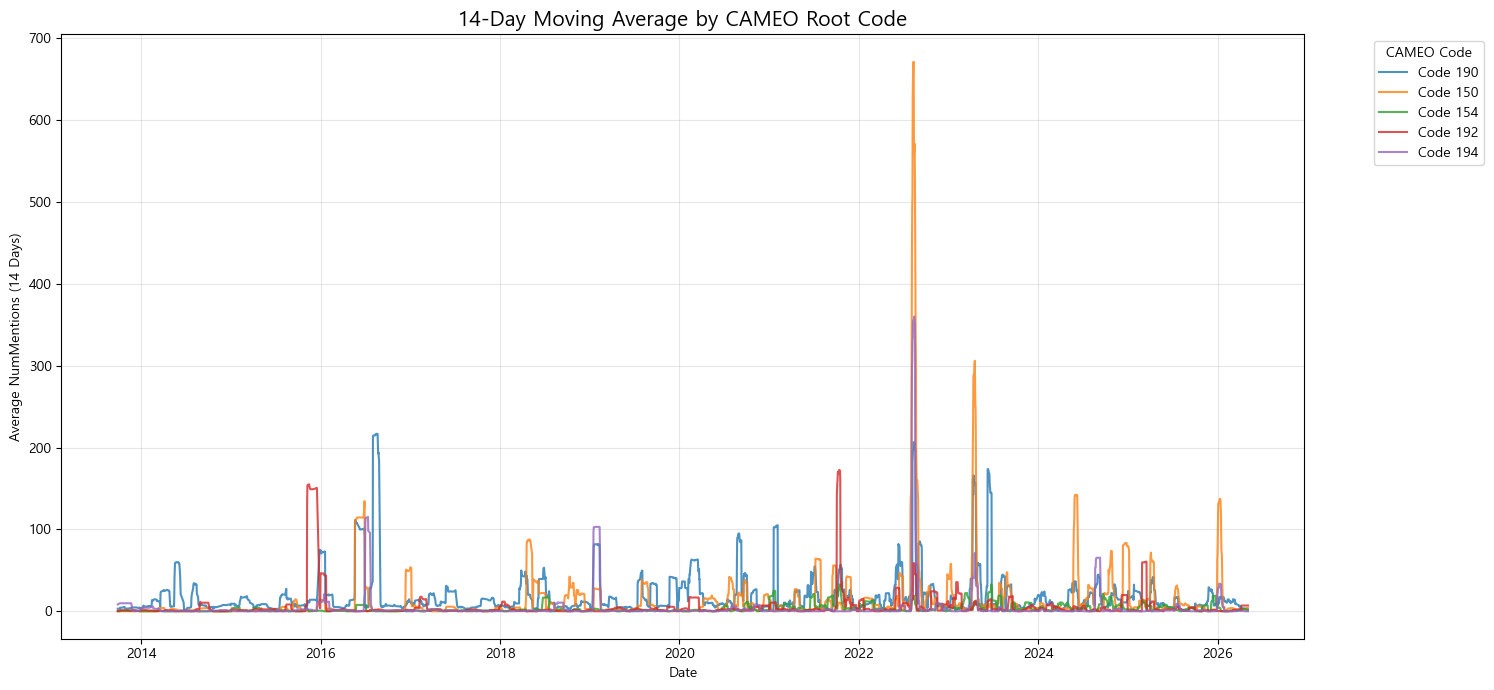

In [34]:
# 1. 날짜와 EventRootCode별로 기사량 합계 산출
# EventRootCode는 CAMEO의 대분류(01~20)를 의미합니다.
cameo_daily = df.groupby(['SQLDATE', 'EventCode'])['NumMentions'].sum().unstack(fill_value=0)

# 2. 코드별 14일 이동평균(Rolling Mean) 계산
cameo_14d_ma = cameo_daily.rolling(window=14).mean()

# 3. 데이터가 가장 많은 상위 5개~10개 코드만 선택하여 시각화 (그래프 복잡도 방지)
top_codes = df['EventCode'].value_counts().head(5).index
selected_ma = cameo_14d_ma[top_codes]

# 4. 시각화
plt.figure(figsize=(15, 7))
for code in selected_ma.columns:
    plt.plot(selected_ma.index, selected_ma[code], label=f'Code {code}', alpha=0.8)

plt.title('14-Day Moving Average by CAMEO Root Code', fontsize=15)
plt.ylabel('Average NumMentions (14 Days)')
plt.xlabel('Date')
plt.legend(title='CAMEO Code', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

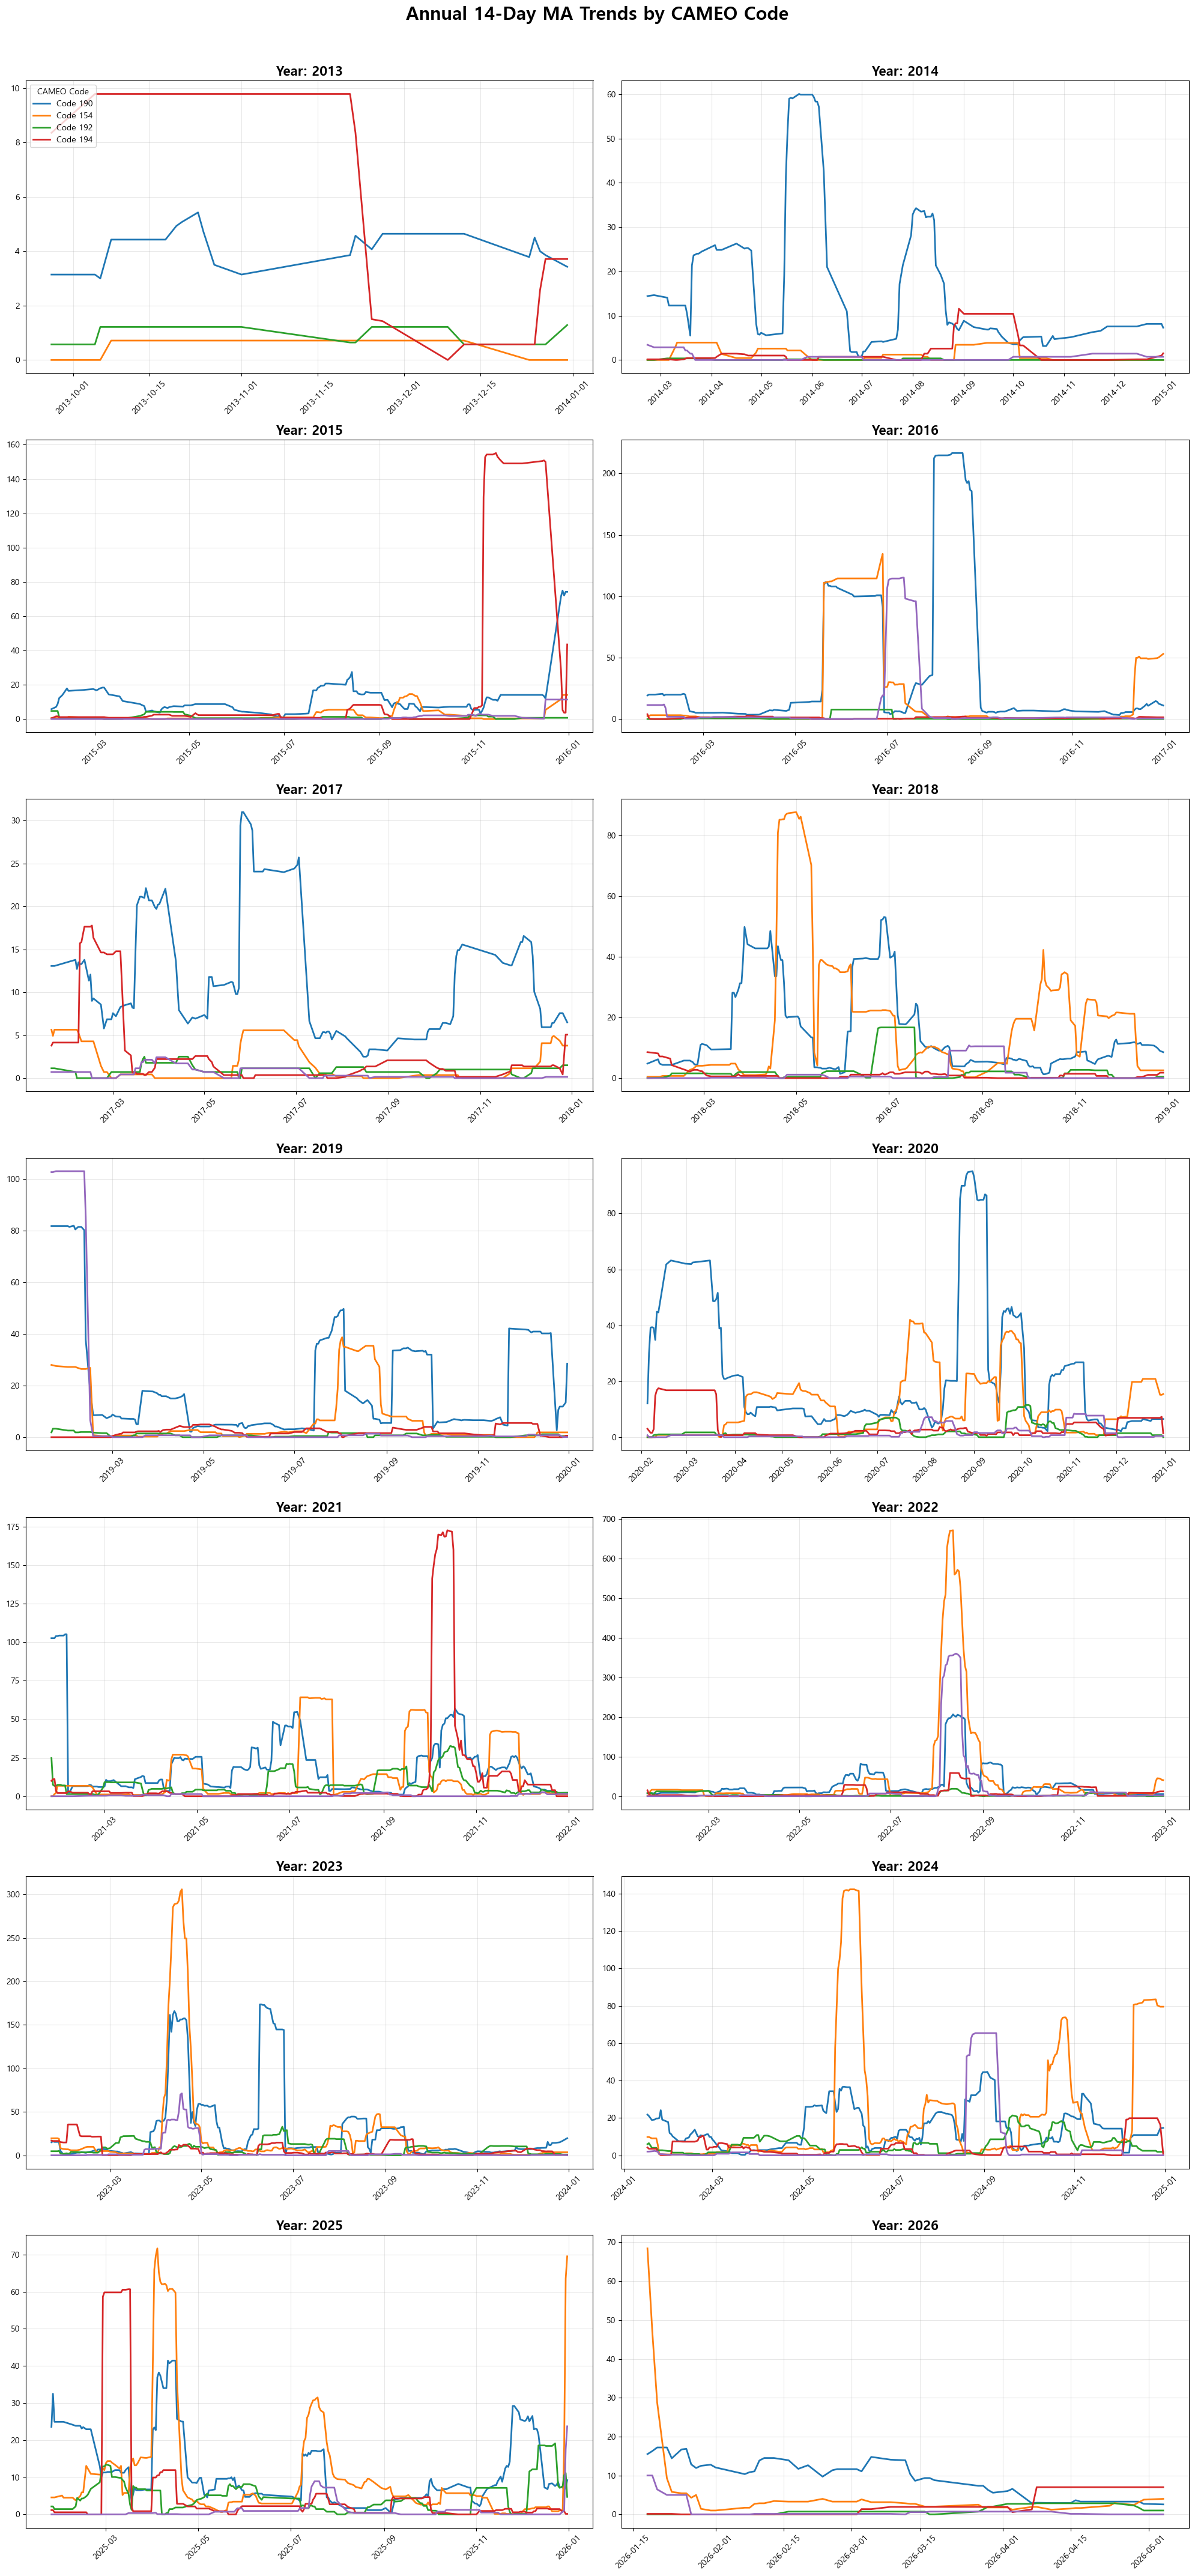

In [35]:
# 1. 연도 컬럼 생성 및 데이터 재구조화
df['Year'] = df['SQLDATE'].dt.year
years = sorted(df['Year'].unique())
top_codes = df['EventCode'].value_counts().head(5).index

# 2. 서브플롯 설정 (한 줄에 2개 연도씩 배치)
cols = 2
rows = math.ceil(len(years) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 6), sharey=False)
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    # 해당 연도 데이터 필터링 및 14일 이동평균 계산
    yearly_df = df[df['Year'] == year].groupby(['SQLDATE', 'EventCode'])['NumMentions'].sum().unstack(fill_value=0)
    yearly_ma = yearly_df.rolling(window=14).mean()
    
    # 상위 코드별로 플로팅
    for code in top_codes:
        if code in yearly_ma.columns:
            ax.plot(yearly_ma.index, yearly_ma[code], label=f'Code {code}', linewidth=2)
    
    ax.set_title(f'Year: {year}', fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    if i == 0:
        ax.legend(title='CAMEO Code', loc='upper left')

# 남는 서브플롯 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Annual 14-Day MA Trends by CAMEO Code', fontsize=22, y=1.02, fontweight='bold')
plt.show()